# 07: Difference-In-Differences DID

We work through difference-in-differences with `DoubleML`. The goal is to make the causal design feel concrete before touching the package API.

Difference-in-differences, usually shortened to DID, is used when one group receives a treatment after a time cutoff and another comparable group does not. The basic idea is simple: compare how the treated group changed over time to how the control group changed over the same time period. The causal content comes from the assumption that, without treatment, the treated group would have followed the same trend as the control group after conditioning on the right pre-treatment information.

We use synthetic data so that the true effect is known. That makes the lesson useful for learning: we can see when raw DID works, when it fails, and how DoubleML uses nuisance learning to adjust for observed differences between treated and control groups.

## Learning Goals

By the end, you should be able to:

- describe the DID estimand in potential-outcome language;
- distinguish panel DID from repeated cross-section DID;
- explain why parallel trends is an identification assumption, not a model fit metric;
- build `DoubleMLDIDData` objects for panel and repeated cross-section settings;
- fit `DoubleMLDID` and `DoubleMLDIDCS` with regression and propensity nuisance learners;
- read nuisance diagnostics, propensity overlap plots, placebo checks, and stress tests;
- write cautious DID conclusions that separate estimates from assumptions.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Difference-In-Differences DID**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment uses panel or repeated-observation structure. The central identifying idea is a comparison of changes rather than levels.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Difference-in-differences compares outcome changes, not levels. In the simplest two-period design,

$$
\tau_{DID}=\{\mathbb{E}(Y_1-Y_0\mid D=1)\}-\{\mathbb{E}(Y_1-Y_0\mid D=0)\}.
$$

The identifying assumption is parallel trends,

$$
\mathbb{E}\{Y_1(0)-Y_0(0)\mid D=1\}=\mathbb{E}\{Y_1(0)-Y_0(0)\mid D=0\}.
$$

Machine learning can adjust for covariates and improve precision, but it cannot create parallel trends.





## Tutorial Workflow

### The DID Problem

The common two-period DID setting has four cells:

- control group before treatment;
- control group after treatment;
- treated group before treatment;
- treated group after treatment.

The treatment is more than the group label. The treated group receives the treatment only in the post period. In symbols, if `D` marks the treated group and `T` marks the post period, actual exposure is `D * T`.

The raw DID contrast is:

```text
(mean outcome treated post - mean outcome treated pre)
- (mean outcome control post - mean outcome control pre)
```

This subtracts away time shocks that both groups share. The design is powerful because it can remove stable group differences and common time shocks. It is also fragile because it does not automatically remove group-specific trends.

### Potential Outcomes and Parallel Trends

For each unit, imagine two post-period outcomes:

- the post outcome if the unit is treated;
- the post outcome if the unit is not treated.

For treated units, we observe the treated post outcome. The missing counterfactual is what their post outcome would have been without treatment. DID fills that missing counterfactual using the control group's change over time.

The key assumption is parallel trends. In the simplest unconditional version:

```text
E[untreated post outcome - untreated pre outcome | treated group]
=
E[untreated post outcome - untreated pre outcome | control group]
```

That assumption is often too strong. In applied work, treated and control groups may differ in pre-period engagement, activity, product fit, risk, or demographics. DoubleML targets a conditional version: after conditioning on pre-treatment covariates `X`, the untreated trend for the treated group is comparable to the untreated trend for controls.

This is still an assumption. Machine learning can help estimate the nuisance functions. The observed covariate set still needs a design argument.

### What DoubleML Adds

DID can be combined with flexible nuisance models. For panel data with two periods, DoubleML works with the outcome change:

```text
Delta Y = Y_post - Y_pre
```

The important nuisance functions are:

- `g0(0, X)`: the expected untreated outcome change among controls, conditional on covariates;
- `g0(1, X)`: the expected outcome change among treated units, conditional on covariates;
- `m0(X)`: the probability that a unit belongs to the treated group.

The propensity model `m0(X)` matters when treatment-group membership is observational rather than randomized. DoubleML uses cross-fitting so the nuisance predictions for each observation are produced by models that did not train on that observation. The score is designed to be Neyman-orthogonal, meaning small nuisance-model errors have a reduced first-order effect on the final treatment estimate.

#### Panel DID versus Repeated Cross Sections

This lesson covers two DID data structures.

Panel DID observes the same units before and after treatment. The natural outcome for DoubleML is the within-unit change, `Y_post - Y_pre`. This is efficient because stable unit-level differences are differenced out.

Repeated cross-section DID observes different samples before and after treatment. There is no unit-level change. Instead, the model compares outcome levels across the four group-time cells while learning conditional outcome functions for each cell.

DoubleML has separate estimators for these cases:

- `DoubleMLDID` for two-period panel DID;
- `DoubleMLDIDCS` for two-period repeated cross-section DID.

The installed package version used here exposes these class names. Some future versions may expose renamed binary-treatment DID classes; the workflow and assumptions are the same idea.

#### Runtime Note

This lesson fits several DoubleML models, including repeated sample splits and small stress tests. On a typical laptop, a full run should take about 2 to 4 minutes. The synthetic samples are large enough to make the diagnostics stable but small enough to keep the tutorial interactive.

#### Setup

The setup cell imports the scientific Python stack, configures output folders, suppresses package deprecation notices that would otherwise distract from the lesson, and records package versions. The warning filters are intentionally narrow: they keep tutorial output readable while still allowing ordinary runtime errors to surface.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*", category=Warning)
warnings.filterwarnings("ignore", message="DoubleMLDID.*deprecated.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="DoubleMLDIDCS.*deprecated.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="DoubleMLDIDData.*deprecated.*", category=DeprecationWarning)

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import sklearn
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.formula.api as smf

import doubleml as dml
from doubleml import DoubleMLDID, DoubleMLDIDCS, DoubleMLDIDData

NOTEBOOK_PREFIX = "07"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

package_versions = pd.DataFrame(
    [
        {"package": "python", "version": os.sys.version.split()[0]},
        {"package": "doubleml", "version": dml.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "matplotlib", "version": plt.matplotlib.__version__},
        {"package": "seaborn", "version": sns.__version__},
    ]
)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,python,3.11.15
1,doubleml,0.11.2
2,numpy,2.4.4
3,pandas,3.0.2
4,scikit-learn,1.6.1
5,matplotlib,3.10.9
6,seaborn,0.13.2


The version table is part of the reproducibility record. DID behavior can depend on package version because estimator class names and optional APIs evolve over time. The notebook uses the classes available in the installed environment and keeps the causal assumptions explicit so the tutorial remains conceptually portable.

#### Helper Functions

The helper functions below keep the notebook focused on causal ideas. They save tables consistently, build reusable learners, summarize DID contrasts, extract DoubleML predictions, and compute simple diagnostics.

The comments are intentionally specific. DID notebooks can become confusing quickly because there are several related quantities: group labels, post-period labels, actual exposure, raw DID contrasts, covariate-adjusted estimates, and DoubleML estimates.

In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, file_name, index=False):
    """
    Save a table under the notebook output folder and return the DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    file_name : str
        Readable label for `file`.
    index : object
        Position of a row, variable, fold, or plotted node in the relevant ordered object.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / file_name
    df.to_csv(path, index=index)
    return df


def sigmoid(x):
    """
    Numerically stable enough logistic transform for the synthetic designs in this lesson.
    
    Parameters
    ----------
    x : str or array-like
        First variable, column name, or numeric input in the local calculation.
    
    Returns
    -------
    np.ndarray
        Probability-scale values obtained by applying the logistic transform elementwise.
    """
    return 1.0 / (1.0 + np.exp(-x))


def rmse(y_true, y_pred):
    """
    Root mean squared error with arrays coerced to one dimension.
    
    Parameters
    ----------
    y_true : array-like
        Reference or oracle values used for evaluation.
    y_pred : array-like
        Predicted or estimated values being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel())))


def clip_probability(values, lower=0.01, upper=0.99):
    """
    Clip propensity-style predictions away from 0 and 1 to avoid unstable inverse weights.
    
    Parameters
    ----------
    values : array-like
        Numeric values transformed, standardized, summarized, or plotted by the helper.
    lower : object
        Lower coordinate, lower interval bound, or lower plotting boundary used by the helper.
    upper : object
        Upper coordinate, upper interval bound, or upper plotting boundary used by the helper.
    
    Returns
    -------
    np.ndarray
        Probability vector clipped to the requested lower and upper bounds.
    """
    return np.clip(np.asarray(values, dtype=float), lower, upper)


def predict_probability(model, X):
    """
    Return P(class=1) from a classifier that implements predict_proba.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    X : object
        Covariate matrix used by the estimator, learner, or intervention function.
    
    Returns
    -------
    np.ndarray
        Predicted probability of the positive class for each evaluation row.
    """
    return model.predict_proba(X)[:, 1]


def make_linear_learners():
    """
    Low-variance nuisance learners that match the mostly linear synthetic design.
    
    Returns
    -------
    tuple
        Tuple containing ml_g, ml_m.
    """
    ml_g = make_pipeline(StandardScaler(), LinearRegression())
    ml_m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000))
    return ml_g, ml_m


def make_hgb_learners(seed=RANDOM_SEED, max_iter=90):
    """
    Tree-based nuisance learners for flexible, nonlinear adjustment.
    
    Parameters
    ----------
    seed : int
        Random seed for reproducible simulation or resampling.
    max_iter : object
        Maximum number of learner iterations used for fitting.
    
    Returns
    -------
    tuple
        Tuple containing ml_g, ml_m.
    """
    ml_g = HistGradientBoostingRegressor(
        max_iter=max_iter,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        learning_rate=0.06,
        random_state=seed,
    )
    ml_m = HistGradientBoostingClassifier(
        max_iter=max_iter,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        learning_rate=0.06,
        random_state=seed,
    )
    return ml_g, ml_m


def raw_panel_did(df, y_col="delta_weekly_value", d_col="treated"):
    """
    For panel data, raw DID is the treated-control difference in outcome changes.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    y_col : str
        Outcome column name.
    d_col : str
        Treatment column name.
    
    Returns
    -------
    tuple
        Tuple containing float(treated_mean - control_mean), grouped.
    """
    grouped = df.groupby(d_col)[y_col].agg(["mean", "std", "size"]).reset_index()
    treated_mean = grouped.loc[grouped[d_col] == 1, "mean"].iloc[0]
    control_mean = grouped.loc[grouped[d_col] == 0, "mean"].iloc[0]
    return float(treated_mean - control_mean), grouped


def raw_repeated_cs_did(df, y_col="weekly_value", d_col="treated", t_col="post"):
    """
    For repeated cross sections, raw DID uses the four group-time cell means.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    y_col : str
        Outcome column name.
    d_col : str
        Treatment column name.
    t_col : object
        Treatment column name used in the DID or panel design.
    
    Returns
    -------
    tuple
        Tuple containing float(estimate), cell_means.
    """
    cell_means = df.groupby([d_col, t_col])[y_col].mean().unstack(t_col)
    estimate = (cell_means.loc[1, 1] - cell_means.loc[1, 0]) - (cell_means.loc[0, 1] - cell_means.loc[0, 0])
    return float(estimate), cell_means


def summarize_doubleml(model, label, design, true_target):
    """
    Create a compact one-row summary from a fitted DoubleML object.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    label : str
        Readable label attached to the method, scenario, or output row.
    design : object
        Readable design label used to distinguish estimators or simulation settings.
    true_target : float
        Oracle causal target used to evaluate bias.
    
    Returns
    -------
    dict[str, float]
        DoubleML summary row with estimator label, design label, estimate, standard error, interval, target, and bias.
    """
    ci = model.confint(level=0.95).iloc[0]
    theta = float(model.coef[0])
    se = float(model.se[0])
    return {
        "estimator": label,
        "design": design,
        "theta_hat": theta,
        "std_error": se,
        "ci_95_lower": float(ci.iloc[0]),
        "ci_95_upper": float(ci.iloc[1]),
        "true_target": float(true_target),
        "bias_vs_target": theta - float(true_target),
    }


def prediction_vector(model, key):
    """
    Extract a DoubleML nuisance prediction array as a flat vector.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    key : object
        Prediction dictionary key identifying which stored nuisance prediction to extract.
    
    Returns
    -------
    np.ndarray
        One-dimensional prediction array aligned with the evaluation rows.
    """
    return np.asarray(model.predictions[key]).reshape(-1)


def learner_loss_table(model, model_label):
    """
    Convert DoubleML learner-loss output into a tidy table.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    model_label : str
        Readable label for `model`.
    
    Returns
    -------
    pd.DataFrame
        Out-of-fold nuisance prediction loss table by learner and nuisance role.
    """
    losses = model.evaluate_learners()
    rows = []
    for learner_name, values in losses.items():
        rows.append(
            {
                "model": model_label,
                "learner": learner_name,
                "metric_value": float(np.asarray(values).mean()),
                "metric": "RMSE for outcome learners; classification error style score for propensity learner",
            }
        )
    return pd.DataFrame(rows)


def add_ci_columns(df):
    """
    Prepare symmetric error-bar columns for estimate plots.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Copy of the input table with lower and upper confidence-interval columns added.
    """
    out = df.copy()
    out["lower_error"] = out["theta_hat"] - out["ci_95_lower"]
    out["upper_error"] = out["ci_95_upper"] - out["theta_hat"]
    return out


These helpers do not hide any causal logic. They simply keep repeated output formatting from crowding the tutorial. The core DID calculations still appear directly in later cells.

#### Teaching Diagram

Before generating data, it helps to draw the design. The arrows below separate three ideas:

- pre-treatment covariates influence whether a unit belongs to the treated group;
- time affects outcomes for everyone;
- the actual treatment occurs only for treated-group units in the post period.

The dashed path marks the danger zone: treated and control groups can have different untreated trends. DID is credible only when those trend differences are absent or can be made comparable after conditioning on observed covariates.

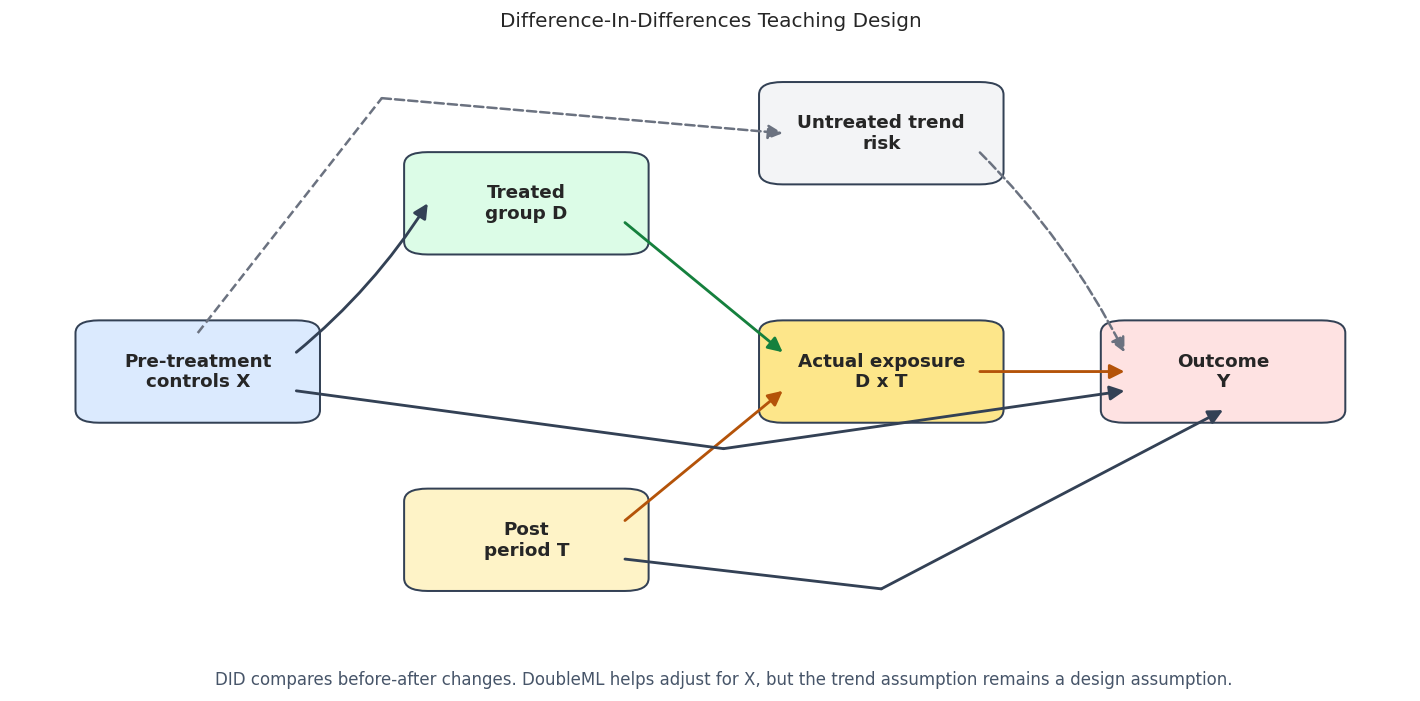

In [3]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

nodes = {
    "X": {"xy": (0.10, 0.52), "label": "Pre-treatment\ncontrols X", "color": "#dbeafe"},
    "D": {"xy": (0.35, 0.76), "label": "Treated\ngroup D", "color": "#dcfce7"},
    "T": {"xy": (0.35, 0.28), "label": "Post\nperiod T", "color": "#fef3c7"},
    "A": {"xy": (0.62, 0.52), "label": "Actual exposure\nD x T", "color": "#fde68a"},
    "Y": {"xy": (0.88, 0.52), "label": "Outcome\nY", "color": "#fee2e2"},
    "R": {"xy": (0.62, 0.86), "label": "Untreated trend\nrisk", "color": "#f3f4f6"},
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()
box_w, box_h = 0.15, 0.11


def anchor(node, side):
    """
    Return a border point on a node box so arrows do not start from hidden centers.
    
    Parameters
    ----------
    node : str
        Graph node name whose position or edge information is needed.
    side : object
        Side of a plotted node where an arrow or label should attach.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return (x + dx, y + dy)


def draw_arrow(start, end, color, style="solid", rad=0.0, linewidth=1.7):
    """
    Draw one visible arrow between already-chosen border points.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    color : str
        Color used for the plotted element.
    style : object
        Line or marker style used to distinguish plotted elements.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used for the plotted curve, edge, or reference line.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        shrinkA=0,
        shrinkB=0,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
    )
    ax.add_patch(arrow)


def draw_routed_arrow(points, color, style="solid", linewidth=1.7):
    """
    Draw a routed arrow where early segments are lines and only the final segment has an arrowhead.
    
    Parameters
    ----------
    points : list[tuple[float, float]]
        Polyline points used to route an arrow.
    color : str
        Color used for the plotted element.
    style : object
        Line or marker style used to distinguish plotted elements.
    linewidth : object
        Line width used for the plotted curve, edge, or reference line.
    
    Returns
    -------
    None
        Adds a routed arrow annotation directly to the supplied Matplotlib axes.
    """
    for start, end in zip(points[:-2], points[1:-1]):
        ax.plot(
            [start[0], end[0]],
            [start[1], end[1]],
            color=color,
            linestyle=style,
            linewidth=linewidth,
            zorder=5,
        )
    draw_arrow(points[-2], points[-1], color=color, style=style, linewidth=linewidth)

# Direct arrows that can be drawn clearly between adjacent boxes.
draw_arrow(anchor("X", "upper_right"), anchor("D", "left"), color="#334155", rad=0.08)
draw_arrow(anchor("D", "lower_right"), anchor("A", "upper_left"), color="#15803d")
draw_arrow(anchor("T", "upper_right"), anchor("A", "lower_left"), color="#b45309")
draw_arrow(anchor("A", "right"), anchor("Y", "left"), color="#b45309")
draw_arrow(anchor("R", "lower_right"), anchor("Y", "upper_left"), color="#6b7280", style="dashed", rad=-0.08, linewidth=1.5)

# Routed arrows avoid passing behind the D, A, and Y boxes.
draw_routed_arrow([anchor("X", "top"), (0.24, 0.91), anchor("R", "left")], color="#6b7280", style="dashed", linewidth=1.5)
draw_routed_arrow([anchor("X", "lower_right"), (0.50, 0.41), anchor("Y", "lower_left")], color="#334155")
draw_routed_arrow([anchor("T", "lower_right"), (0.62, 0.21), anchor("Y", "bottom")], color="#334155")

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.08,
    "DID compares before-after changes. DoubleML helps adjust for X, but the trend assumption remains a design assumption.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Difference-In-Differences Teaching Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_did_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The diagram makes the exposure structure explicit. A treated-group label alone is not the treatment. A post-period label alone is not the treatment. The treatment is the interaction of the two.

#### Synthetic Panel Data

The first dataset observes the same units before and after treatment. Treatment-group membership is intentionally observational: high-engagement and high-activity units are more likely to be in the treated group. Those same covariates also affect untreated outcome trends.

That creates a useful teaching setting. The raw DID contrast is biased because treated and control groups have different covariate mixes. Conditional parallel trends is valid in the synthetic design because the untreated trend depends on observed covariates, not on unobserved group-specific shocks.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
N_PANEL = 8_000

engagement_score = rng.normal(0, 1, N_PANEL)
recent_activity = rng.normal(0, 1, N_PANEL)
content_fit = rng.normal(0, 1, N_PANEL)
price_sensitivity = rng.normal(0, 1, N_PANEL)
tenure_signal = rng.uniform(0, 1, N_PANEL)
mobile_user = rng.binomial(1, 0.55, N_PANEL)

panel_x = pd.DataFrame(
    {
        "engagement_score": engagement_score,
        "recent_activity": recent_activity,
        "content_fit": content_fit,
        "price_sensitivity": price_sensitivity,
        "tenure_signal": tenure_signal,
        "mobile_user": mobile_user,
    }
)
feature_cols = list(panel_x.columns)

# Treatment-group membership is observational and depends on pre-treatment covariates.
true_propensity = sigmoid(
    -0.10
    + 0.50 * engagement_score
    + 0.35 * recent_activity
    - 0.35 * price_sensitivity
    + 0.15 * mobile_user
)
treated = rng.binomial(1, true_propensity)

# Baseline levels differ across users, but the panel DID model works with changes.
baseline_level = (
    4.0
    + 0.80 * engagement_score
    + 0.50 * recent_activity
    + 0.70 * content_fit
    - 0.40 * price_sensitivity
    + 0.20 * mobile_user
    + rng.normal(0, 0.60, N_PANEL)
)

# Untreated trends vary with observed covariates. This makes unconditional DID imperfect.
expected_untreated_trend = (
    0.25
    + 0.25 * engagement_score
    + 0.18 * recent_activity
    + 0.12 * content_fit
    - 0.08 * price_sensitivity
    + 0.05 * mobile_user
)
untreated_trend = expected_untreated_trend + rng.normal(0, 0.10, N_PANEL)

# Treatment effects are heterogeneous. The target for DID is the treated-group average post effect.
true_tau = 1.00 + 0.35 * engagement_score + 0.25 * content_fit - 0.15 * price_sensitivity + 0.10 * mobile_user

y_pre = baseline_level + rng.normal(0, 0.45, N_PANEL)
y_post = baseline_level + untreated_trend + true_tau * treated + rng.normal(0, 0.45, N_PANEL)
delta_weekly_value = y_post - y_pre

panel_df = pd.concat(
    [
        pd.DataFrame({"unit_id": np.arange(N_PANEL)}),
        panel_x,
        pd.DataFrame(
            {
                "treated": treated,
                "y_pre": y_pre,
                "y_post": y_post,
                "delta_weekly_value": delta_weekly_value,
                "expected_untreated_trend": expected_untreated_trend,
                "true_untreated_trend": untreated_trend,
                "true_tau": true_tau,
                "true_propensity": true_propensity,
            }
        ),
    ],
    axis=1,
)

TRUE_PANEL_ATT = panel_df.loc[panel_df["treated"] == 1, "true_tau"].mean()
TRUE_PANEL_ATE = panel_df["true_tau"].mean()

panel_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_panel_did.csv"
panel_df.to_csv(panel_path, index=False)

print(f"Panel rows: {len(panel_df):,}")
print(f"True panel ATT: {TRUE_PANEL_ATT:.4f}")
print(f"True panel ATE: {TRUE_PANEL_ATE:.4f}")
print(f"Saved panel data to: {panel_path.relative_to(PROJECT_ROOT)}")
display(panel_df.head())


Panel rows: 8,000
True panel ATT: 1.1606
True panel ATE: 1.0594
Saved panel data to: notebooks/tutorials/doubleml/outputs/datasets/07_synthetic_panel_did.csv


,unit_id,engagement_score,recent_activity,content_fit,price_sensitivity,tenure_signal,mobile_user,treated,y_pre,y_post,delta_weekly_value,expected_untreated_trend,true_untreated_trend,true_tau,true_propensity
0,0,0.304717,0.333602,-1.322489,-0.422500,0.572782,1,0,3.907776,5.766276,1.858501,0.311329,0.374285,0.939404,0.614672
1,1,-1.039984,1.236343,1.389147,0.969549,0.251107,1,0,5.808336,6.529171,0.720835,0.351679,0.202828,0.937860,0.406944
2,2,0.750451,1.215829,-0.348241,-0.432650,0.371131,0,1,4.734420,6.621476,1.887057,0.649285,0.752185,1.240495,0.701027
3,3,0.940565,-0.450957,-0.071824,0.354970,0.233027,0,0,4.650214,5.758102,1.107888,0.366952,0.434669,1.257996,0.522038
4,4,-1.951035,0.194017,0.283535,-0.125404,0.236977,0,1,3.023087,2.352221,-0.670866,-0.158779,-0.199061,0.406832,0.276134


The true ATT is larger than the true ATE because higher-effect units are more likely to be in the treated group. This is not a bug. DID with a treated-group policy usually targets the effect for the treated group, not necessarily the population-wide average effect.

#### Panel Field Dictionary

A field dictionary turns the synthetic dataset into a readable teaching object. It also mirrors good applied workflow: before fitting any causal model, make the unit, treatment, time, outcome, and covariate roles explicit.

| field | role | description |
| --- | --- | --- |
| unit_id | identifier | Unique unit observed before and after treatment. |
| treated | group indicator | Equals 1 for units in the treated group; treatment exposure happens only after the policy starts. |
| y_pre | pre outcome | Outcome measured before treatment exposure. |
| y_post | post outcome | Outcome measured after treated-group units receive exposure. |
| delta_weekly_value | DID outcome | Within-unit change, y_post minus y_pre, used by panel DID. |
| engagement_score | covariate | Pre-treatment engagement signal that affects group membership and trends. |
| recent_activity | covariate | Pre-treatment activity signal. |
| content_fit | covariate | Pre-treatment fit signal related to outcomes and treatment effects. |
| price_sensitivity | covariate | Pre-treatment risk or sensitivity signal. |
| tenure_signal | covariate | Pre-treatment tenure-like signal. |
| mobile_user | covariate | Binary pre-treatment segment marker. |
| expected_untreated_trend | simulation truth | Expected no-treatment trend given observed covariates. |
| true_untreated_trend | simulation truth | Realized no-treatment trend including noise. |
| true_tau | simulation truth | Individual treatment effect in the post period. |
| true_propensity | simulation truth | True probability of treated-group membership. |


The key modeling outcome for panel DID is `delta_weekly_value`. The pre and post outcome columns remain useful for plotting, raw checks, and sanity checks, but the DoubleML panel DID estimator consumes the change directly.




## Diagnostics and Interpretation

### Basic Panel Data Audit

A DID audit should check sample size, missingness, treatment balance, and outcome ranges before any estimator is fitted. The code below keeps the checks simple and transparent.

In [5]:
panel_audit = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "missing_cells",
            "treated_share",
            "mean_pre_outcome",
            "mean_post_outcome",
            "mean_outcome_change",
        ],
        "value": [
            len(panel_df),
            panel_df.shape[1],
            int(panel_df.isna().sum().sum()),
            panel_df["treated"].mean(),
            panel_df["y_pre"].mean(),
            panel_df["y_post"].mean(),
            panel_df["delta_weekly_value"].mean(),
        ],
    }
)
save_table(panel_audit, f"{NOTEBOOK_PREFIX}_panel_data_audit.csv")
display(panel_audit)


,metric,value
0,rows,8000.000000
1,columns,15.000000
2,missing_cells,0.000000
3,treated_share,0.491625
4,mean_pre_outcome,4.116102
5,mean_post_outcome,4.968973
6,mean_outcome_change,0.852871


The treated share is close to one half, so the tutorial has enough observations in both groups. In applied DID, a tiny treated group or tiny control group would make weighting, overlap, and standard errors much more fragile.




## Reporting and Takeaways

### Target Summary

Because this is synthetic data, we can compute the true targets. The ATT is the main DID target here because the estimand asks: among units that actually entered the treated group, what was the average post-period treatment effect?

In [6]:
panel_target_summary = pd.DataFrame(
    [
        {"target": "panel ATT", "value": TRUE_PANEL_ATT, "meaning": "Average true treatment effect among treated-group units."},
        {"target": "panel ATE", "value": TRUE_PANEL_ATE, "meaning": "Average true treatment effect over all units."},
        {"target": "treated share", "value": panel_df["treated"].mean(), "meaning": "Share of units in the treated group."},
        {"target": "mean true propensity", "value": panel_df["true_propensity"].mean(), "meaning": "Average probability of treated-group membership."},
    ]
)
save_table(panel_target_summary, f"{NOTEBOOK_PREFIX}_panel_target_summary.csv")
display(panel_target_summary)

,target,value,meaning
0,panel ATT,1.160608,Average true treatment effect among treated-group units.
1,panel ATE,1.059387,Average true treatment effect over all units.
2,treated share,0.491625,Share of units in the treated group.
3,mean true propensity,0.493144,Average probability of treated-group membership.


The ATT and ATE differ because treatment effects vary and treated-group membership is selective. A strong report should name the target clearly instead of saying only that DID estimated "the effect."



### Covariate Balance by Treatment Group

DID is observational unless the assignment mechanism is randomized. The table below compares treated and control groups on pre-treatment covariates. Large differences make unconditional parallel trends less plausible, even when DID may still be defensible with stronger design evidence.

In [7]:
balance_rows = []
for col in feature_cols:
    treated_mean = panel_df.loc[panel_df["treated"] == 1, col].mean()
    control_mean = panel_df.loc[panel_df["treated"] == 0, col].mean()
    pooled_sd = panel_df[col].std(ddof=1)
    balance_rows.append(
        {
            "feature": col,
            "treated_mean": treated_mean,
            "control_mean": control_mean,
            "difference": treated_mean - control_mean,
            "standardized_difference": (treated_mean - control_mean) / pooled_sd,
        }
    )

panel_balance = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=np.abs, ascending=False)
save_table(panel_balance, f"{NOTEBOOK_PREFIX}_panel_covariate_balance.csv")
display(panel_balance)


,feature,treated_mean,control_mean,difference,standardized_difference
0,engagement_score,0.223692,-0.235643,0.459335,0.458236
1,recent_activity,0.159149,-0.170904,0.330054,0.328654
3,price_sensitivity,-0.141904,0.163144,-0.305048,-0.302151
5,mobile_user,0.560386,0.537251,0.023135,0.046488
2,content_fit,0.019964,0.058889,-0.038925,-0.039005
4,tenure_signal,0.502406,0.502485,-0.000079,-0.000272


The covariate differences are deliberate. They create the reason to use an observational DID score with nuisance adjustment rather than relying entirely on the raw two-by-two comparison.

### Treatment Propensity and Overlap

The propensity here is the probability of belonging to the treated group. DID needs enough overlap: for similar covariate profiles, we should see both treated and control units. When overlap is weak, the estimator has to extrapolate or assign large weights.

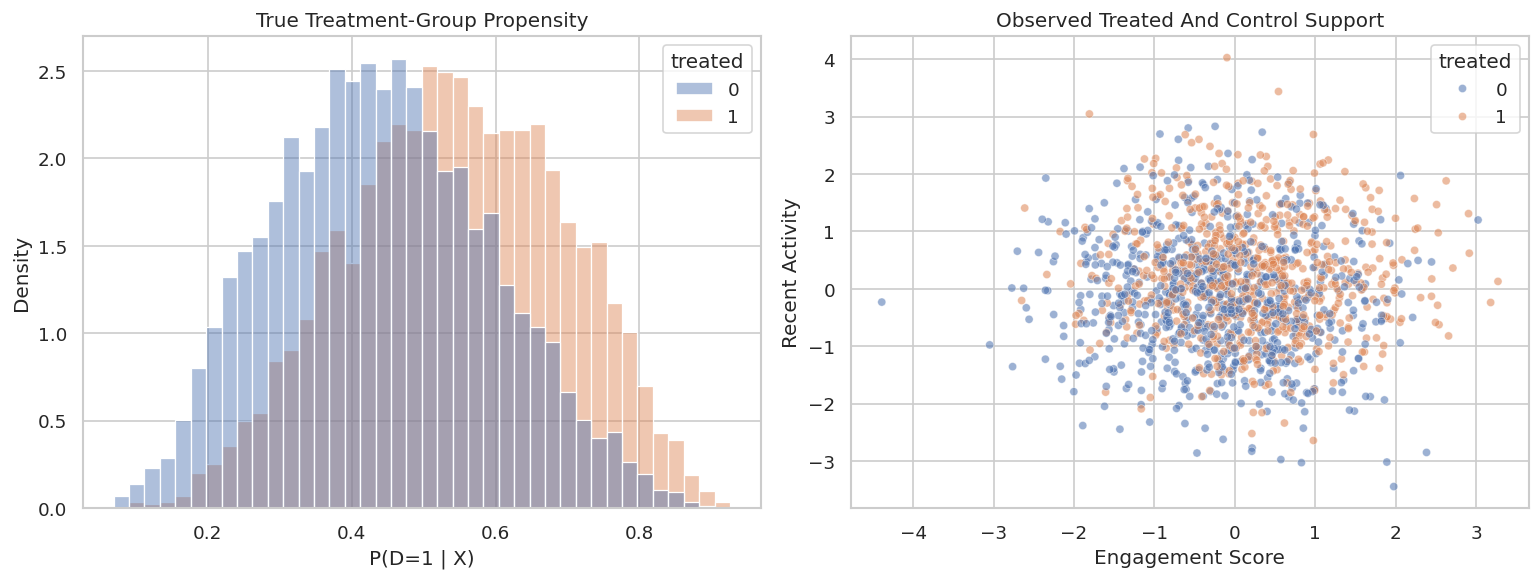

In [8]:
# Build and label the diagnostic visualization for the Treatment Propensity And Overlap section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=panel_df,
    x="true_propensity",
    hue="treated",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("True Treatment-Group Propensity")
axes[0].set_xlabel("P(D=1 | X)")
axes[0].set_ylabel("Density")

sns.scatterplot(
    data=panel_df.sample(1_500, random_state=RANDOM_SEED),
    x="engagement_score",
    y="recent_activity",
    hue="treated",
    alpha=0.55,
    s=24,
    ax=axes[1],
)
axes[1].set_title("Observed Treated And Control Support")
axes[1].set_xlabel("Engagement Score")
axes[1].set_ylabel("Recent Activity")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_panel_true_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The overlap is imperfect, and both groups appear across most of the support. This is a reasonable worked case because adjustment matters while the model avoids completely unsupported regions.



### Raw Panel DID

For panel data, raw DID is very simple: compute each unit's before-after change and compare the average change between treated and control groups. This removes stable unit-level differences but does not adjust for covariate-related trends.

In [9]:
raw_panel_estimate, panel_change_by_group = raw_panel_did(panel_df)

raw_panel_summary = pd.DataFrame(
    [
        {
            "estimator": "Raw panel DID",
            "design": "panel",
            "theta_hat": raw_panel_estimate,
            "true_target": TRUE_PANEL_ATT,
            "bias_vs_target": raw_panel_estimate - TRUE_PANEL_ATT,
        }
    ]
)
save_table(panel_change_by_group, f"{NOTEBOOK_PREFIX}_panel_change_by_group.csv")
save_table(raw_panel_summary, f"{NOTEBOOK_PREFIX}_raw_panel_did_summary.csv")

display(panel_change_by_group)
display(raw_panel_summary)


,treated,mean,std,size
0,0,0.182551,0.727967,4067
1,1,1.546029,0.967813,3933


,estimator,design,theta_hat,true_target,bias_vs_target
0,Raw panel DID,panel,1.363479,1.160608,0.202871


The raw DID estimate is above the true ATT. The treated group has covariates associated with stronger no-treatment trends, so a simple before-after comparison attributes too much of the natural trend difference to the treatment.

### Visualizing the Four Panel Means

Even though panel DID uses outcome changes, the classic four-cell plot is still useful. It shows the pre and post outcome levels for each group and makes the DID contrast easier to explain.

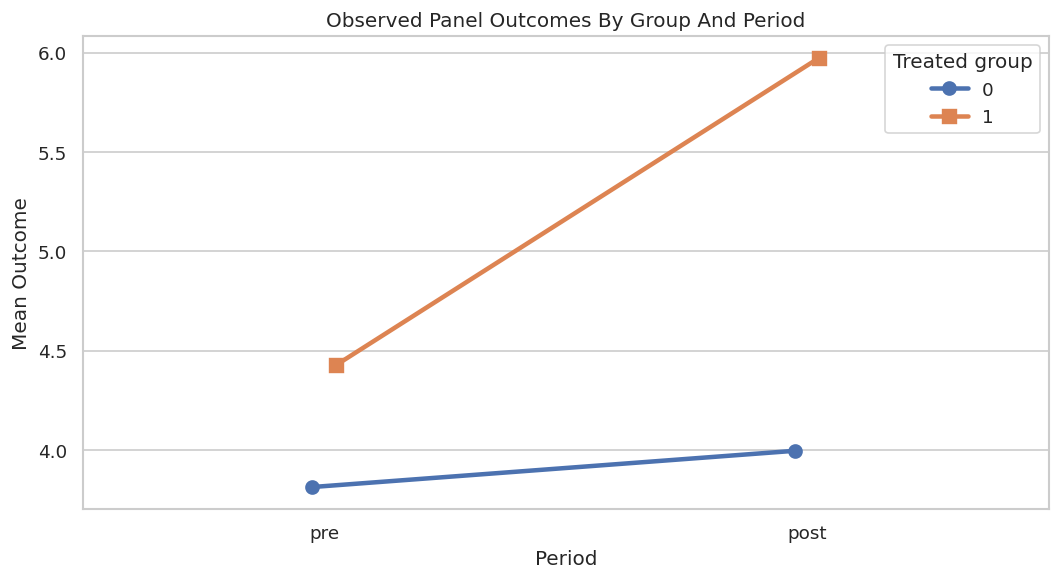

,treated,period,mean,se,n
0,0,post,3.996322,0.026942,4067
1,0,pre,3.813771,0.022440,4067
2,1,post,5.974763,0.032450,3933
3,1,pre,4.428733,0.022632,3933


In [10]:
# Build and label the diagnostic visualization for the Visualizing The Four Panel Means section.
panel_long = panel_df.melt(
    id_vars=["unit_id", "treated"],
    value_vars=["y_pre", "y_post"],
    var_name="period",
    value_name="weekly_value",
)
panel_long["period"] = panel_long["period"].map({"y_pre": "pre", "y_post": "post"})

panel_means = (
    panel_long.groupby(["treated", "period"])["weekly_value"]
    .agg(mean="mean", se=lambda x: x.std(ddof=1) / np.sqrt(len(x)), n="size")
    .reset_index()
)
save_table(panel_means, f"{NOTEBOOK_PREFIX}_panel_four_cell_means.csv")

fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(
    data=panel_means,
    x="period",
    y="mean",
    hue="treated",
    order=["pre", "post"],
    markers=["o", "s"],
    linestyles=["-", "-"],
    dodge=0.05,
    errorbar=None,
    ax=ax,
)
ax.set_title("Observed Panel Outcomes By Group And Period")
ax.set_xlabel("Period")
ax.set_ylabel("Mean Outcome")
ax.legend(title="Treated group")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_panel_four_cell_means.png", dpi=160, bbox_inches="tight")
plt.show()

display(panel_means)


The treated group starts higher and grows more. DID asks whether the extra growth is treatment impact or whether treated units would have grown faster anyway. The synthetic truth says part of the extra growth is pre-treatment covariate composition.

#### Regression Baselines

A useful baseline is an OLS regression of the outcome change on the treatment-group indicator and covariates. This serves a different role than the same as the orthogonal DoubleML score. It gives a transparent reference point.

In [11]:
formula = "delta_weekly_value ~ treated + " + " + ".join(feature_cols)
ols_panel = smf.ols(formula=formula, data=panel_df).fit(cov_type="HC3")

ols_panel_summary = pd.DataFrame(
    [
        {
            "estimator": "OLS on outcome change with covariates",
            "design": "panel",
            "theta_hat": float(ols_panel.params["treated"]),
            "std_error": float(ols_panel.bse["treated"]),
            "ci_95_lower": float(ols_panel.conf_int().loc["treated", 0]),
            "ci_95_upper": float(ols_panel.conf_int().loc["treated", 1]),
            "true_target": TRUE_PANEL_ATT,
            "bias_vs_target": float(ols_panel.params["treated"] - TRUE_PANEL_ATT),
        }
    ]
)
save_table(ols_panel_summary, f"{NOTEBOOK_PREFIX}_panel_ols_baseline.csv")
display(ols_panel_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,OLS on outcome change with covariates,panel,1.075332,0.016391,1.043206,1.107457,1.160608,-0.085276


The covariate-adjusted regression moves closer to the target than raw DID. DoubleML will use a related adjustment idea, but with cross-fitted nuisance models and an orthogonal score that is less sensitive to regularization error.



#### Manual Cross-Fitted DID Score

Before using the package estimator, we can compute a small manual version of the observational panel DID score. The control outcome-change model estimates what treated units would have experienced without treatment, while the propensity model reweights controls to look more like the treated group.

This manual implementation is included for intuition. The DoubleML estimator should be preferred for serious work because it handles score details, inference, sample splitting, and repeated splits consistently.

In [12]:
def crossfit_panel_dr_did(df, y_col, d_col, x_cols, ml_g, ml_m, n_splits=5, seed=RANDOM_SEED):
    """
    Idea: Cross-fit the nuisance models for the crossfit panel dr difference-in-differences design so evaluation uses out-of-fold predictions.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    y_col : str
        Name of the outcome column.
    d_col : str
        Name of the treatment column.
    x_cols : list[str]
        Covariate column names used as model inputs.
    ml_g : object
        Outcome-regression learner used by the DoubleML score.
    ml_m : object
        Treatment or propensity nuisance learner used by the DoubleML estimator.
    n_splits : object
        Number of folds or sample splits used for cross-fitting.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple[dict, pd.DataFrame]
        DID effect summary and fold-level nuisance diagnostics.
    """
    X = df[x_cols].reset_index(drop=True)
    y = df[y_col].to_numpy()
    d = df[d_col].to_numpy()
    n = len(df)

    g0_hat = np.full(n, np.nan)
    m_hat = np.full(n, np.nan)
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for train_idx, test_idx in splitter.split(X, d):
        control_train_idx = train_idx[d[train_idx] == 0]

        g_model = clone(ml_g)
        m_model = clone(ml_m)

        # The untreated trend model is trained only on controls.
        g_model.fit(X.iloc[control_train_idx], y[control_train_idx])
        g0_hat[test_idx] = g_model.predict(X.iloc[test_idx])

        # The propensity model is trained on all training observations.
        m_model.fit(X.iloc[train_idx], d[train_idx])
        m_hat[test_idx] = predict_probability(m_model, X.iloc[test_idx])

    m_hat = clip_probability(m_hat)
    treated_share = d.mean()
    control_weight = (1 - d) * m_hat / (1 - m_hat)
    normalized_control_weight = control_weight / control_weight.mean()

    score_contribution = (d / treated_share - normalized_control_weight) * (y - g0_hat)
    theta_hat = score_contribution.mean()
    std_error = score_contribution.std(ddof=1) / np.sqrt(n)

    summary = pd.DataFrame(
        [
            {
                "estimator": "Manual cross-fitted DR panel DID",
                "design": "panel",
                "theta_hat": theta_hat,
                "std_error": std_error,
                "ci_95_lower": theta_hat - 1.96 * std_error,
                "ci_95_upper": theta_hat + 1.96 * std_error,
                "true_target": TRUE_PANEL_ATT,
                "bias_vs_target": theta_hat - TRUE_PANEL_ATT,
                "treated_share": treated_share,
                "mean_control_weight": control_weight.mean(),
            }
        ]
    )
    diagnostics = pd.DataFrame(
        {
            "g0_hat": g0_hat,
            "m_hat": m_hat,
            "score_contribution": score_contribution,
            "treated": d,
            "outcome_change": y,
        }
    )
    return summary, diagnostics

linear_g, linear_m = make_linear_learners()
manual_panel_summary, manual_panel_diagnostics = crossfit_panel_dr_did(
    panel_df,
    y_col="delta_weekly_value",
    d_col="treated",
    x_cols=feature_cols,
    ml_g=linear_g,
    ml_m=linear_m,
    n_splits=5,
    seed=RANDOM_SEED,
)
save_table(manual_panel_summary, f"{NOTEBOOK_PREFIX}_manual_panel_dr_did.csv")
save_table(manual_panel_diagnostics.describe().reset_index(), f"{NOTEBOOK_PREFIX}_manual_panel_diagnostics.csv")
display(manual_panel_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target,treated_share,mean_control_weight
0,Manual cross-fitted DR panel DID,panel,1.170154,0.022568,1.125921,1.214386,1.160608,0.009546,0.491625,0.495287


The manual score lands near the true ATT and gives us a bridge to DoubleML. The score contribution column is also useful later because it shows how individual residualized observations combine into the final estimate.

#### Manual Score Diagnostics

The next plot checks the two pieces that drive the manual score: estimated propensities and score contributions. Extreme propensities or heavy-tailed score contributions would be a warning sign.

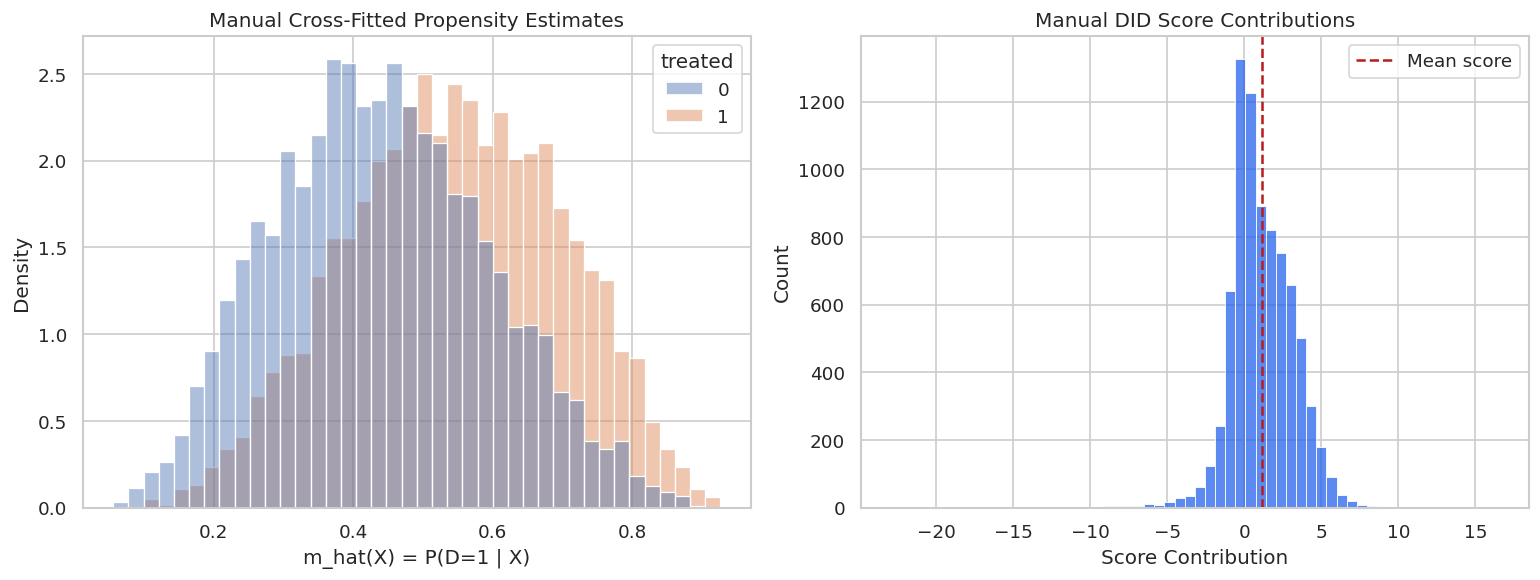

In [13]:
# Build and label the diagnostic visualization for the Manual Score Diagnostics section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=manual_panel_diagnostics,
    x="m_hat",
    hue="treated",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Manual Cross-Fitted Propensity Estimates")
axes[0].set_xlabel("m_hat(X) = P(D=1 | X)")
axes[0].set_ylabel("Density")

sns.histplot(
    data=manual_panel_diagnostics,
    x="score_contribution",
    bins=60,
    color="#2563eb",
    ax=axes[1],
)
axes[1].axvline(manual_panel_summary["theta_hat"].iloc[0], color="#b91c1c", linestyle="--", label="Mean score")
axes[1].set_title("Manual DID Score Contributions")
axes[1].set_xlabel("Score Contribution")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_panel_score_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


The propensity estimates have overlap across groups, and the score distribution is centered around the manual estimate without a small number of observations dominating the plot. This makes the full DoubleML fit more trustworthy as a worked example.



#### DoubleML Panel Data Backend

`DoubleMLDIDData` tells DoubleML which column is the outcome change, which column marks the treated group, and which columns are pre-treatment covariates. For panel DID, we do not pass a time column because the outcome has already been collapsed to a before-after difference.

In [14]:
panel_dml_data = DoubleMLDIDData(
    panel_df,
    y_col="delta_weekly_value",
    d_cols="treated",
    x_cols=feature_cols,
)

panel_backend_summary = pd.DataFrame(
    [
        {"property": "n_obs", "value": panel_dml_data.n_obs},
        {"property": "outcome", "value": panel_dml_data.y_col},
        {"property": "treatment", "value": ", ".join(panel_dml_data.d_cols)},
        {"property": "n_covariates", "value": len(panel_dml_data.x_cols)},
        {"property": "covariates", "value": ", ".join(panel_dml_data.x_cols)},
    ]
)
save_table(panel_backend_summary, f"{NOTEBOOK_PREFIX}_panel_doublemldata_backend.csv")
display(panel_backend_summary)


,property,value
0,n_obs,8000
1,outcome,delta_weekly_value
2,treatment,treated
3,n_covariates,6
4,covariates,"engagement_score, recent_activity, content_fit, price_sensitivity, tenure_signal, mobile_user"


This backend object is the contract between the dataset and the estimator. If any role is wrong here, the estimator can run successfully while answering the wrong causal question.

#### Fit `DoubleMLDID`

We fit three panel DID models:

- observational score with linear nuisance learners;
- observational score with gradient boosting nuisance learners;
- experimental score with gradient boosting outcome learners.

The observational score is appropriate when treated-group membership depends on covariates. The experimental score is included as a contrast: it is what we would use if group assignment were as-if randomized with respect to pre-treatment covariates.

In [15]:
# Fit or evaluate the model objects used in the Fit `DoubleMLDID` section.
panel_model_rows = []
panel_models = {}

ml_g_linear, ml_m_linear = make_linear_learners()
panel_did_linear = DoubleMLDID(
    panel_dml_data,
    ml_g=ml_g_linear,
    ml_m=ml_m_linear,
    n_folds=5,
    score="observational",
)
panel_did_linear.fit(store_predictions=True)
panel_models["Panel observational linear"] = panel_did_linear
panel_model_rows.append(summarize_doubleml(panel_did_linear, "Panel observational linear", "panel", TRUE_PANEL_ATT))

ml_g_hgb, ml_m_hgb = make_hgb_learners(seed=RANDOM_SEED + 7, max_iter=90)
panel_did_hgb = DoubleMLDID(
    panel_dml_data,
    ml_g=ml_g_hgb,
    ml_m=ml_m_hgb,
    n_folds=5,
    score="observational",
)
panel_did_hgb.fit(store_predictions=True)
panel_models["Panel observational HGB"] = panel_did_hgb
panel_model_rows.append(summarize_doubleml(panel_did_hgb, "Panel observational HGB", "panel", TRUE_PANEL_ATT))

ml_g_exp, _ = make_hgb_learners(seed=RANDOM_SEED + 17, max_iter=90)
panel_did_experimental = DoubleMLDID(
    panel_dml_data,
    ml_g=ml_g_exp,
    n_folds=5,
    score="experimental",
)
panel_did_experimental.fit(store_predictions=True)
panel_models["Panel experimental HGB"] = panel_did_experimental
panel_model_rows.append(summarize_doubleml(panel_did_experimental, "Panel experimental HGB", "panel", TRUE_PANEL_ATT))

panel_doubleml_summary = pd.DataFrame(panel_model_rows)
save_table(panel_doubleml_summary, f"{NOTEBOOK_PREFIX}_panel_doubleml_did_summary.csv")
display(panel_doubleml_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Panel observational linear,panel,1.169871,0.018216,1.134168,1.205574,1.160608,0.009263
1,Panel observational HGB,panel,1.170317,0.018395,1.134264,1.206370,1.160608,0.009709
2,Panel experimental HGB,panel,1.086258,0.015553,1.055776,1.116741,1.160608,-0.074349


The observational DoubleML estimates are close to the true ATT. The experimental score is less appropriate for this simulated design because treated-group membership was not randomized; the comparison is a reminder that the score choice should match the assignment story.



#### Panel Estimate Comparison

The next figure puts raw DID, OLS adjustment, the manual cross-fitted score, and DoubleML estimates on one scale. A plot like this is useful in applied notebooks because it makes the consequence of adjustment visible.

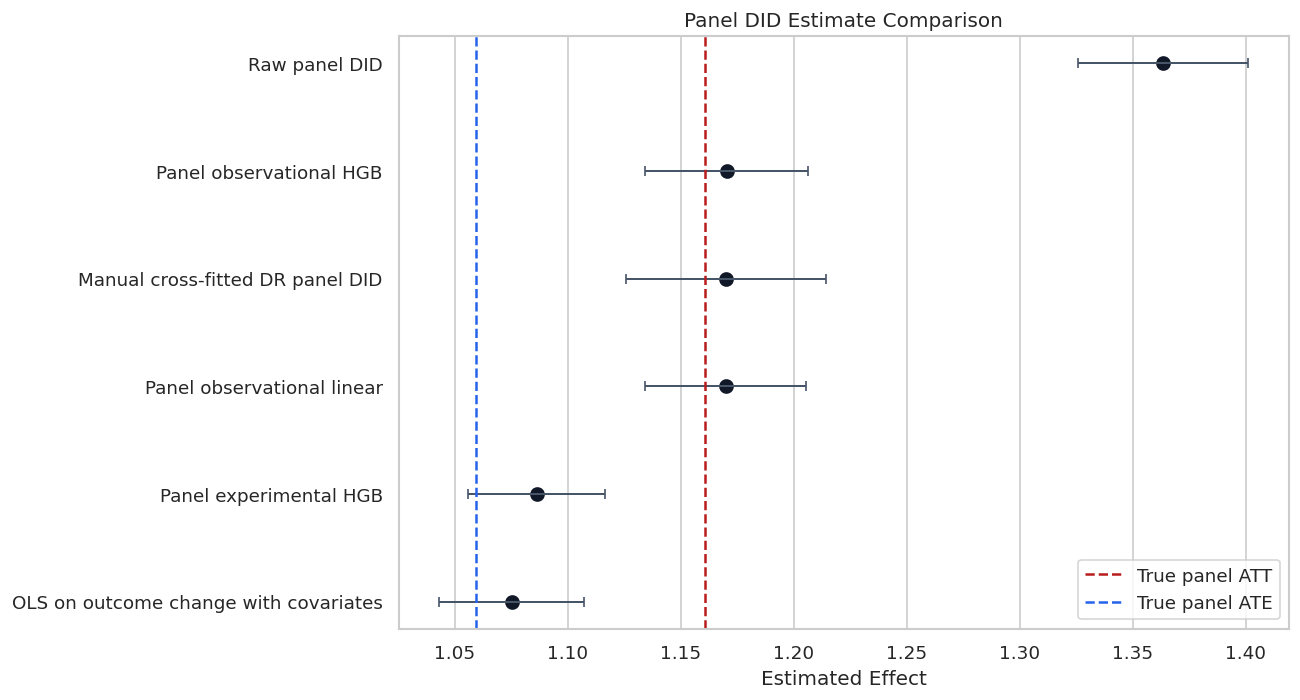

,estimator,design,theta_hat,true_target,bias_vs_target,std_error,ci_95_lower,ci_95_upper
0,Raw panel DID,panel,1.363479,1.160608,0.202871,0.019195,1.325856,1.401101
1,OLS on outcome change with covariates,panel,1.075332,1.160608,-0.085276,0.016391,1.043206,1.107457
2,Manual cross-fitted DR panel DID,panel,1.170154,1.160608,0.009546,0.022568,1.125921,1.214386
3,Panel observational linear,panel,1.169871,1.160608,0.009263,0.018216,1.134168,1.205574
4,Panel observational HGB,panel,1.170317,1.160608,0.009709,0.018395,1.134264,1.206370
5,Panel experimental HGB,panel,1.086258,1.160608,-0.074349,0.015553,1.055776,1.116741


In [16]:
# Build and label the diagnostic visualization for the Panel Estimate Comparison section.
panel_estimates = pd.concat(
    [
        raw_panel_summary.assign(std_error=np.nan, ci_95_lower=np.nan, ci_95_upper=np.nan),
        ols_panel_summary,
        manual_panel_summary.drop(columns=["treated_share", "mean_control_weight"]),
        panel_doubleml_summary,
    ],
    ignore_index=True,
)

# Add approximate intervals for the raw estimate using a simple group-difference standard error.
raw_group_var = panel_df.groupby("treated")["delta_weekly_value"].agg(["var", "size"])
raw_se = np.sqrt(raw_group_var.loc[1, "var"] / raw_group_var.loc[1, "size"] + raw_group_var.loc[0, "var"] / raw_group_var.loc[0, "size"])
panel_estimates.loc[panel_estimates["estimator"] == "Raw panel DID", "std_error"] = raw_se
panel_estimates.loc[panel_estimates["estimator"] == "Raw panel DID", "ci_95_lower"] = raw_panel_estimate - 1.96 * raw_se
panel_estimates.loc[panel_estimates["estimator"] == "Raw panel DID", "ci_95_upper"] = raw_panel_estimate + 1.96 * raw_se

save_table(panel_estimates, f"{NOTEBOOK_PREFIX}_panel_estimate_comparison.csv")
plot_panel_estimates = add_ci_columns(panel_estimates)

fig, ax = plt.subplots(figsize=(11, 6))
order = plot_panel_estimates.sort_values("theta_hat", ascending=False)["estimator"]
sns.pointplot(
    data=plot_panel_estimates,
    y="estimator",
    x="theta_hat",
    order=order,
    linestyle="none",
    color="#111827",
    errorbar=None,
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_panel_estimates.set_index("estimator").loc[order].reset_index().iterrows()):
    ax.errorbar(
        x=row["theta_hat"],
        y=y_pos,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="#475569",
        capsize=3,
        linewidth=1.2,
    )
ax.axvline(TRUE_PANEL_ATT, color="#b91c1c", linestyle="--", linewidth=1.5, label="True panel ATT")
ax.axvline(TRUE_PANEL_ATE, color="#2563eb", linestyle="--", linewidth=1.5, label="True panel ATE")
ax.set_title("Panel DID Estimate Comparison")
ax.set_xlabel("Estimated Effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_panel_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(panel_estimates)


The raw panel DID estimate is the outlier because it mixes treatment effects with covariate-driven trend differences. The adjusted estimates are much closer to the true treated-group effect.

#### Panel Nuisance Learner Diagnostics

DoubleML relies on nuisance learners, so we should inspect them. The loss table below is not a causal validity test. It tells us whether the predictive components are behaving reasonably.

In [17]:
panel_loss_tables = []
for label, model in panel_models.items():
    panel_loss_tables.append(learner_loss_table(model, label))

panel_nuisance_losses = pd.concat(panel_loss_tables, ignore_index=True)
save_table(panel_nuisance_losses, f"{NOTEBOOK_PREFIX}_panel_nuisance_losses.csv")
display(panel_nuisance_losses)

,model,learner,metric_value,metric
0,Panel observational linear,ml_g0,0.648214,RMSE for outcome learners; classification error style score for propensity learner
1,Panel observational linear,ml_g1,0.662468,RMSE for outcome learners; classification error style score for propensity learner
2,Panel observational linear,ml_m,0.473424,RMSE for outcome learners; classification error style score for propensity learner
3,Panel observational HGB,ml_g0,0.657088,RMSE for outcome learners; classification error style score for propensity learner
4,Panel observational HGB,ml_g1,0.676860,RMSE for outcome learners; classification error style score for propensity learner
5,Panel observational HGB,ml_m,0.477063,RMSE for outcome learners; classification error style score for propensity learner
6,Panel experimental HGB,ml_g0,0.657243,RMSE for outcome learners; classification error style score for propensity learner
7,Panel experimental HGB,ml_g1,0.683162,RMSE for outcome learners; classification error style score for propensity learner


The outcome nuisance losses are on the scale of outcome-change prediction error. The propensity learner score is a classification-style loss. These diagnostics are useful for debugging, but good prediction is not a substitute for parallel trends.



#### Panel Nuisance Predictions Against Synthetic Truth

Because this is a synthetic notebook, we can compare estimated propensities to the true propensities. In real data, the true propensity is unavailable. We can still inspect the distribution of predicted propensities and whether the model is producing extreme weights.

In [18]:
# Save the artifacts produced by the Panel Nuisance Predictions Against Synthetic Truth section.
panel_hgb_predictions = pd.DataFrame(
    {
        "true_propensity": panel_df["true_propensity"],
        "m_hat_hgb": prediction_vector(panel_did_hgb, "ml_m"),
        "g0_hat_hgb": prediction_vector(panel_did_hgb, "ml_g0"),
        "g1_hat_hgb": prediction_vector(panel_did_hgb, "ml_g1"),
        "treated": panel_df["treated"],
        "delta_weekly_value": panel_df["delta_weekly_value"],
        "expected_untreated_trend": panel_df["expected_untreated_trend"],
    }
)

panel_nuisance_quality = pd.DataFrame(
    [
        {
            "quantity": "propensity m_hat",
            "rmse_vs_truth": rmse(panel_hgb_predictions["true_propensity"], panel_hgb_predictions["m_hat_hgb"]),
            "mae_vs_truth": mean_absolute_error(panel_hgb_predictions["true_propensity"], panel_hgb_predictions["m_hat_hgb"]),
        },
        {
            "quantity": "untreated trend g0_hat",
            "rmse_vs_truth": rmse(panel_hgb_predictions["expected_untreated_trend"], panel_hgb_predictions["g0_hat_hgb"]),
            "mae_vs_truth": mean_absolute_error(panel_hgb_predictions["expected_untreated_trend"], panel_hgb_predictions["g0_hat_hgb"]),
        },
    ]
)
save_table(panel_nuisance_quality, f"{NOTEBOOK_PREFIX}_panel_hgb_nuisance_quality.csv")
display(panel_nuisance_quality)


,quantity,rmse_vs_truth,mae_vs_truth
0,propensity m_hat,0.061415,0.047722
1,untreated trend g0_hat,0.127523,0.099828


The synthetic truth check shows that the nuisance learners are capturing the main structure. This gives us confidence that any remaining difference from the true ATT is mostly sampling noise rather than a broken implementation.

#### Panel Propensity Plot

The plot below uses the HGB propensity predictions produced during DoubleML cross-fitting. We want treated and control units to overlap in predicted propensity space.

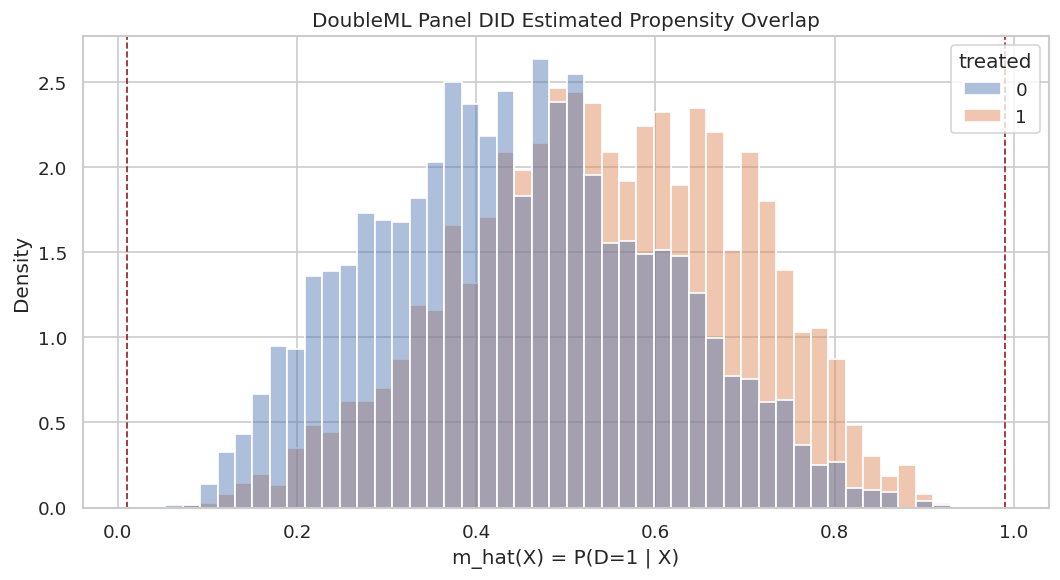

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=panel_hgb_predictions,
    x="m_hat_hgb",
    hue="treated",
    bins=45,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.axvline(0.01, color="#991b1b", linestyle="--", linewidth=1, label="Clipping boundary")
ax.axvline(0.99, color="#991b1b", linestyle="--", linewidth=1)
ax.set_title("DoubleML Panel DID Estimated Propensity Overlap")
ax.set_xlabel("m_hat(X) = P(D=1 | X)")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_panel_estimated_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The mass is away from 0 and 1, and both groups overlap across much of the range. That supports stable weighting in this synthetic example.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->




#### Bootstrap Confidence Interval

DoubleML provides a multiplier bootstrap. Here we bootstrap the HGB observational panel model to show how uncertainty can be reported beyond the default analytic standard error.

In [20]:
panel_did_hgb.bootstrap(method="normal", n_rep_boot=500)
panel_bootstrap_ci = panel_did_hgb.confint(level=0.95).reset_index().rename(columns={"index": "treatment"})
panel_bootstrap_ci["estimator"] = "Panel observational HGB bootstrap CI"
save_table(panel_bootstrap_ci, f"{NOTEBOOK_PREFIX}_panel_hgb_bootstrap_ci.csv")
display(panel_bootstrap_ci)

,treatment,2.5 %,97.5 %,estimator
0,treated,1.134264,1.20637,Panel observational HGB bootstrap CI


The bootstrap interval is another uncertainty view for the same target. It does not address hidden violations of parallel trends; it quantifies sampling uncertainty under the model and design assumptions.



#### Repeated Sample Splitting

Cross-fitting uses random folds. A robust tutorial should show whether the estimate changes materially when the folds change. Large instability would suggest that the nuisance learners or sample size need attention.

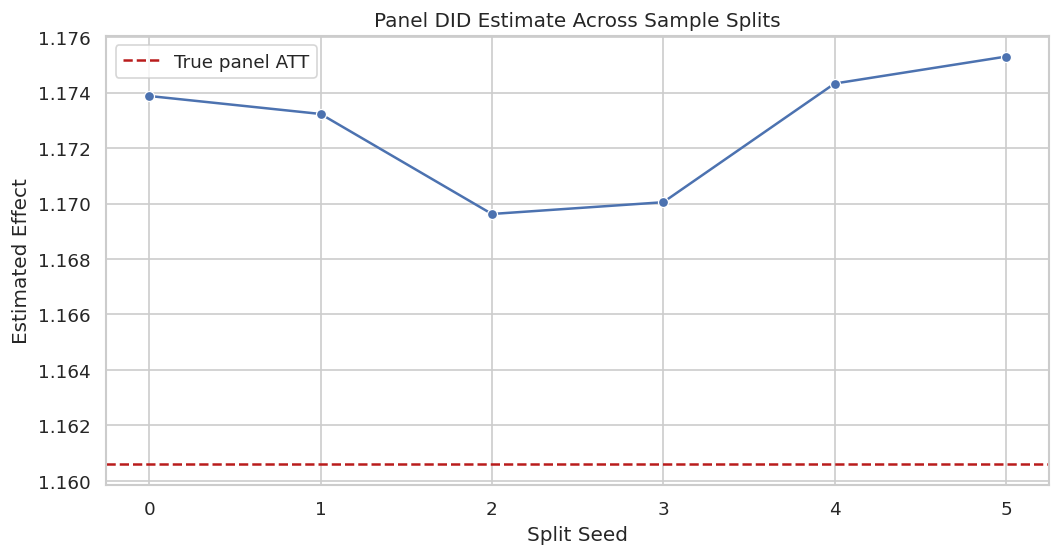

,split_seed,theta_hat,std_error,true_target,bias_vs_target
0,0,1.173875,0.018439,1.160608,0.013267
1,1,1.173227,0.018276,1.160608,0.012619
2,2,1.169623,0.018643,1.160608,0.009015
3,3,1.170047,0.018617,1.160608,0.009439
4,4,1.174323,0.018443,1.160608,0.013716
5,5,1.175295,0.018267,1.160608,0.014688


In [21]:
# Build and label the diagnostic visualization for the Repeated Sample Splitting section.
repeated_rows = []
for split_seed in range(6):
    ml_g_rep, ml_m_rep = make_hgb_learners(seed=RANDOM_SEED + 100 + split_seed, max_iter=70)
    did_rep = DoubleMLDID(
        panel_dml_data,
        ml_g=ml_g_rep,
        ml_m=ml_m_rep,
        n_folds=5,
        score="observational",
    )
    did_rep.fit(store_predictions=False)
    repeated_rows.append(
        {
            "split_seed": split_seed,
            "theta_hat": float(did_rep.coef[0]),
            "std_error": float(did_rep.se[0]),
            "true_target": TRUE_PANEL_ATT,
            "bias_vs_target": float(did_rep.coef[0] - TRUE_PANEL_ATT),
        }
    )

panel_split_stability = pd.DataFrame(repeated_rows)
save_table(panel_split_stability, f"{NOTEBOOK_PREFIX}_panel_repeated_split_stability.csv")

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.lineplot(data=panel_split_stability, x="split_seed", y="theta_hat", marker="o", ax=ax)
ax.axhline(TRUE_PANEL_ATT, color="#b91c1c", linestyle="--", label="True panel ATT")
ax.set_title("Panel DID Estimate Across Sample Splits")
ax.set_xlabel("Split Seed")
ax.set_ylabel("Estimated Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_panel_repeated_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()

display(panel_split_stability)


The estimates move slightly across folds, but the movement is small relative to the treatment effect. That is the kind of stability we want before presenting a final estimate.

#### Placebo Outcome Check

A common DID diagnostic is a placebo pre-trend check. With only one pre period, real data would need additional historical periods. In this synthetic tutorial, we create a fake pre-period change that has no treatment effect. A credible adjusted DID procedure should estimate something close to zero on that placebo outcome.

In [22]:
# Fit or evaluate the model objects used in the Placebo Outcome Check section.
placebo_panel_df = panel_df.copy()
placebo_panel_df["placebo_pre_delta"] = (
    0.15
    + 0.20 * placebo_panel_df["engagement_score"]
    + 0.10 * placebo_panel_df["recent_activity"]
    - 0.06 * placebo_panel_df["price_sensitivity"]
    + rng.normal(0, 0.55, len(placebo_panel_df))
)

placebo_raw_estimate, _ = raw_panel_did(placebo_panel_df, y_col="placebo_pre_delta", d_col="treated")
placebo_data = DoubleMLDIDData(placebo_panel_df, y_col="placebo_pre_delta", d_cols="treated", x_cols=feature_cols)
ml_g_placebo, ml_m_placebo = make_linear_learners()
placebo_did = DoubleMLDID(
    placebo_data,
    ml_g=ml_g_placebo,
    ml_m=ml_m_placebo,
    n_folds=5,
    score="observational",
)
placebo_did.fit(store_predictions=True)

placebo_summary = pd.DataFrame(
    [
        {"check": "raw placebo DID", "theta_hat": placebo_raw_estimate, "expected_value": 0.0},
        {"check": "DoubleML adjusted placebo DID", "theta_hat": float(placebo_did.coef[0]), "expected_value": 0.0},
    ]
)
placebo_summary["distance_from_zero"] = placebo_summary["theta_hat"].abs()
save_table(placebo_summary, f"{NOTEBOOK_PREFIX}_panel_placebo_check.csv")
display(placebo_summary)


,check,theta_hat,expected_value,distance_from_zero
0,raw placebo DID,0.148949,0.0,0.148949
1,DoubleML adjusted placebo DID,-0.005413,0.0,0.005413


The adjusted placebo estimate is closer to zero than the raw placebo contrast. In real work, a nonzero placebo estimate would require a serious explanation.



#### Parallel Trend Violation Stress Test

Now we intentionally break the DID assumption by adding an unobserved treated-group trend shock. This shock is not explained by `X`, so neither OLS nor DoubleML can fix it. The point is to show the boundary of machine learning: nuisance adjustment helps with observed confounding, not hidden trend violations.

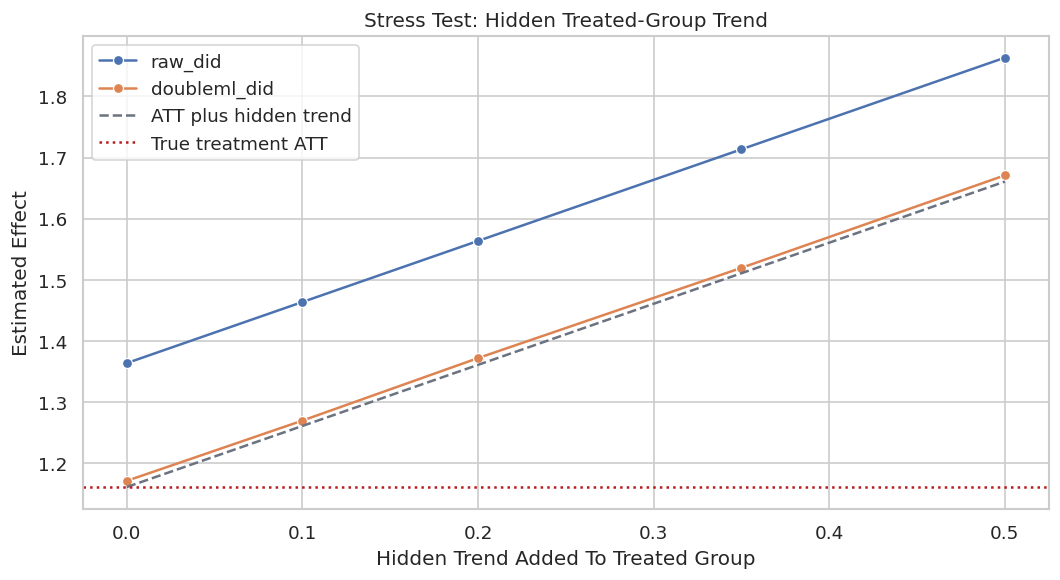

,hidden_trend_added_to_treated,raw_did,doubleml_did,true_treatment_att,expected_biased_target
0,0.00,1.363479,1.170737,1.160608,1.160608
1,0.10,1.463479,1.269369,1.160608,1.260608
2,0.20,1.563479,1.371670,1.160608,1.360608
3,0.35,1.713479,1.519406,1.160608,1.510608
4,0.50,1.863479,1.670897,1.160608,1.660608


In [23]:
# Build and label the diagnostic visualization for the Parallel Trend Violation Stress Test section.
violation_rows = []
for violation_strength in [0.0, 0.10, 0.20, 0.35, 0.50]:
    stress_df = panel_df.copy()
    stress_df["delta_with_hidden_trend"] = stress_df["delta_weekly_value"] + violation_strength * stress_df["treated"]
    stress_data = DoubleMLDIDData(
        stress_df,
        y_col="delta_with_hidden_trend",
        d_cols="treated",
        x_cols=feature_cols,
    )
    ml_g_stress, ml_m_stress = make_linear_learners()
    stress_model = DoubleMLDID(
        stress_data,
        ml_g=ml_g_stress,
        ml_m=ml_m_stress,
        n_folds=5,
        score="observational",
    )
    stress_model.fit(store_predictions=False)
    raw_stress, _ = raw_panel_did(stress_df, y_col="delta_with_hidden_trend", d_col="treated")
    violation_rows.append(
        {
            "hidden_trend_added_to_treated": violation_strength,
            "raw_did": raw_stress,
            "doubleml_did": float(stress_model.coef[0]),
            "true_treatment_att": TRUE_PANEL_ATT,
            "expected_biased_target": TRUE_PANEL_ATT + violation_strength,
        }
    )

parallel_trend_stress = pd.DataFrame(violation_rows)
save_table(parallel_trend_stress, f"{NOTEBOOK_PREFIX}_parallel_trend_violation_stress.csv")

fig, ax = plt.subplots(figsize=(9, 5))
plot_stress = parallel_trend_stress.melt(
    id_vars=["hidden_trend_added_to_treated", "true_treatment_att", "expected_biased_target"],
    value_vars=["raw_did", "doubleml_did"],
    var_name="estimator",
    value_name="estimate",
)
sns.lineplot(
    data=plot_stress,
    x="hidden_trend_added_to_treated",
    y="estimate",
    hue="estimator",
    marker="o",
    ax=ax,
)
ax.plot(
    parallel_trend_stress["hidden_trend_added_to_treated"],
    parallel_trend_stress["expected_biased_target"],
    color="#6b7280",
    linestyle="--",
    label="ATT plus hidden trend",
)
ax.axhline(TRUE_PANEL_ATT, color="#b91c1c", linestyle=":", label="True treatment ATT")
ax.set_title("Stress Test: Hidden Treated-Group Trend")
ax.set_xlabel("Hidden Trend Added To Treated Group")
ax.set_ylabel("Estimated Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_parallel_trend_violation_stress.png", dpi=160, bbox_inches="tight")
plt.show()

display(parallel_trend_stress)


As the hidden trend violation grows, the adjusted DID estimate follows the biased target rather than the true treatment effect. This is the central limitation of DID: the model cannot discover the missing counterfactual trend by itself.



#### Repeated Cross-Section Data

Now we switch to a repeated cross-section design. We no longer observe the same unit twice. Each row is one observation in either the pre or post period.

The group indicator `treated` marks whether an observation belongs to the group that is exposed after the policy begins. The time indicator `post` marks whether the observation is from the post period. Actual exposure is again `treated * post`.

In [24]:
# Save the artifacts produced by the Repeated Cross-Section Data section.
rng_cs = np.random.default_rng(RANDOM_SEED + 1)
N_CS = 10_000

cs_post = rng_cs.binomial(1, 0.50, N_CS)
cs_engagement = rng_cs.normal(0, 1, N_CS)
cs_activity = rng_cs.normal(0, 1, N_CS)
cs_fit = rng_cs.normal(0, 1, N_CS)
cs_price = rng_cs.normal(0, 1, N_CS)
cs_tenure = rng_cs.uniform(0, 1, N_CS)
cs_mobile = rng_cs.binomial(1, 0.55, N_CS)

cs_x = pd.DataFrame(
    {
        "engagement_score": cs_engagement,
        "recent_activity": cs_activity,
        "content_fit": cs_fit,
        "price_sensitivity": cs_price,
        "tenure_signal": cs_tenure,
        "mobile_user": cs_mobile,
    }
)
cs_propensity = sigmoid(-0.10 + 0.50 * cs_engagement + 0.35 * cs_activity - 0.35 * cs_price + 0.15 * cs_mobile)
cs_treated = rng_cs.binomial(1, cs_propensity)

cs_baseline = 4.0 + 0.80 * cs_engagement + 0.50 * cs_activity + 0.70 * cs_fit - 0.40 * cs_price + 0.20 * cs_mobile
cs_expected_trend = 0.25 + 0.25 * cs_engagement + 0.18 * cs_activity + 0.12 * cs_fit - 0.08 * cs_price + 0.05 * cs_mobile
cs_tau = 1.00 + 0.35 * cs_engagement + 0.25 * cs_fit - 0.15 * cs_price + 0.10 * cs_mobile

cs_weekly_value = cs_baseline + cs_expected_trend * cs_post + cs_tau * cs_treated * cs_post + rng_cs.normal(0, 0.65, N_CS)

cs_df = pd.concat(
    [
        pd.DataFrame({"row_id": np.arange(N_CS)}),
        cs_x,
        pd.DataFrame(
            {
                "treated": cs_treated,
                "post": cs_post,
                "actual_exposure": cs_treated * cs_post,
                "weekly_value": cs_weekly_value,
                "expected_untreated_trend": cs_expected_trend,
                "true_tau": cs_tau,
                "true_propensity": cs_propensity,
            }
        ),
    ],
    axis=1,
)

TRUE_CS_ATT = cs_df.loc[cs_df["treated"] == 1, "true_tau"].mean()
TRUE_CS_ATE = cs_df["true_tau"].mean()

cs_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_repeated_cs_did.csv"
cs_df.to_csv(cs_path, index=False)

print(f"Repeated cross-section rows: {len(cs_df):,}")
print(f"True repeated cross-section ATT: {TRUE_CS_ATT:.4f}")
print(f"True repeated cross-section ATE: {TRUE_CS_ATE:.4f}")
print(f"Saved repeated cross-section data to: {cs_path.relative_to(PROJECT_ROOT)}")
display(cs_df.head())


Repeated cross-section rows: 10,000
True repeated cross-section ATT: 1.1592
True repeated cross-section ATE: 1.0478
Saved repeated cross-section data to: notebooks/tutorials/doubleml/outputs/datasets/07_synthetic_repeated_cs_did.csv


,row_id,engagement_score,recent_activity,content_fit,price_sensitivity,tenure_signal,mobile_user,treated,post,actual_exposure,weekly_value,expected_untreated_trend,true_tau,true_propensity
0,0,0.367609,0.424735,-1.386468,0.482572,0.317388,1,1,1,1,4.052319,0.263373,0.809660,0.553188
1,1,1.716114,1.940829,-1.712124,0.622154,0.023020,1,1,0,0,5.214719,0.823151,1.179286,0.797314
2,2,-1.491408,0.459025,0.579608,0.075518,0.023211,0,0,0,0,3.721336,0.023284,0.611581,0.329273
3,3,2.219092,0.681663,-0.414447,-0.007063,0.720072,0,0,1,0,6.626428,0.878304,1.674130,0.777404
4,4,-1.688694,-2.586733,1.250442,-0.811638,0.334672,1,0,1,0,3.360712,-0.372801,0.943313,0.195348


The repeated cross-section dataset has no `y_pre` or `y_post` columns for the same unit. That is why the estimator has to model outcome levels in the four group-time cells rather than within-unit changes.

#### Repeated Cross-Section Field Dictionary

The field roles are similar to the panel design, but the time column is now explicit. `post` must be passed to the DoubleML data backend for repeated cross-section DID.

| field | role | description |
| --- | --- | --- |
| row_id | identifier | Unique row in the repeated cross-section sample. |
| treated | group indicator | Equals 1 for observations from the group exposed in the post period. |
| post | time indicator | Equals 1 for post-period observations. |
| actual_exposure | realized treatment | Interaction treated x post. |
| weekly_value | outcome | Observed outcome level for that row and period. |
| feature columns | covariates | Observed pre-treatment or baseline covariates used for conditional DID. |
| expected_untreated_trend | simulation truth | Expected no-treatment trend given observed covariates. |
| true_tau | simulation truth | Individual post-period treatment effect. |
| true_propensity | simulation truth | True probability of belonging to the treated group. |


The important structural difference is that repeated cross-section DID must know both `treated` and `post`. The package uses `t_col="post"` to identify the time indicator.



#### Repeated Cross-Section Audit and Cell Means

A repeated cross-section DID audit should check the four cells. If one group-time cell is sparse, the design can become unstable.

In [25]:
cs_cell_counts = cs_df.groupby(["treated", "post"]).size().rename("n").reset_index()
cs_raw_estimate, cs_cell_means = raw_repeated_cs_did(cs_df)

cs_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(cs_df)},
        {"metric": "missing_cells", "value": int(cs_df.isna().sum().sum())},
        {"metric": "treated_share", "value": cs_df["treated"].mean()},
        {"metric": "post_share", "value": cs_df["post"].mean()},
        {"metric": "raw_repeated_cs_did", "value": cs_raw_estimate},
        {"metric": "true_cs_att", "value": TRUE_CS_ATT},
    ]
)
save_table(cs_cell_counts, f"{NOTEBOOK_PREFIX}_cs_cell_counts.csv")
save_table(cs_cell_means.reset_index(), f"{NOTEBOOK_PREFIX}_cs_cell_means.csv")
save_table(cs_audit, f"{NOTEBOOK_PREFIX}_cs_data_audit.csv")

display(cs_cell_counts)
display(cs_cell_means)
display(cs_audit)


,treated,post,n
0,0,0,2496
1,0,1,2519
2,1,0,2457
3,1,1,2528


post,0,1
treated,,
0,3.771595,3.953479
1,4.462902,5.939473


,metric,value
0,rows,10000.000000
1,missing_cells,0.000000
2,treated_share,0.498500
3,post_share,0.504700
4,raw_repeated_cs_did,1.294686
5,true_cs_att,1.159164


All four cells are well populated. The raw repeated cross-section DID estimate is informative but still vulnerable to covariate-driven trends because treated and control group membership is observational.



#### Repeated Cross-Section Four-Cell Plot

The repeated cross-section plot is the classic DID picture. Each line connects group means from pre to post, even though the underlying units are not the same people over time.

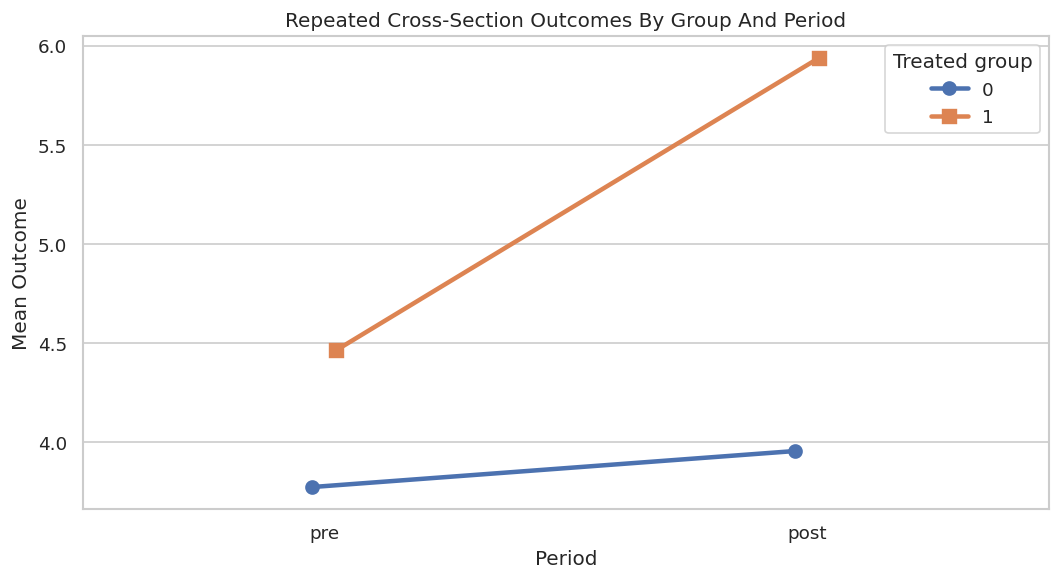

,treated,post,mean,se,n,period
0,0,0,3.771595,0.027247,2496,pre
1,0,1,3.953479,0.033645,2519,post
2,1,0,4.462902,0.027094,2457,pre
3,1,1,5.939473,0.039852,2528,post


In [26]:
# Build and label the diagnostic visualization for the Repeated Cross-Section Four-Cell Plot section.
cs_means = (
    cs_df.groupby(["treated", "post"])["weekly_value"]
    .agg(mean="mean", se=lambda x: x.std(ddof=1) / np.sqrt(len(x)), n="size")
    .reset_index()
)
cs_means["period"] = cs_means["post"].map({0: "pre", 1: "post"})
save_table(cs_means, f"{NOTEBOOK_PREFIX}_cs_four_cell_means.csv")

fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(
    data=cs_means,
    x="period",
    y="mean",
    hue="treated",
    order=["pre", "post"],
    markers=["o", "s"],
    dodge=0.05,
    errorbar=None,
    ax=ax,
)
ax.set_title("Repeated Cross-Section Outcomes By Group And Period")
ax.set_xlabel("Period")
ax.set_ylabel("Mean Outcome")
ax.legend(title="Treated group")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cs_four_cell_means.png", dpi=160, bbox_inches="tight")
plt.show()

display(cs_means)


The treated group's post-period jump is visibly larger. The causal question is whether that extra jump is due to treatment exposure or to the treated group having a different covariate composition and natural trend.

#### Fit `DoubleMLDIDCS`

For repeated cross sections, the backend receives the outcome level, the treated-group indicator, the time indicator, and covariates. The estimator learns outcome nuisance functions for the relevant group-time cells and a propensity model for treated-group membership.

In [27]:
cs_dml_data = DoubleMLDIDData(
    cs_df,
    y_col="weekly_value",
    d_cols="treated",
    t_col="post",
    x_cols=feature_cols,
)

cs_backend_summary = pd.DataFrame(
    [
        {"property": "n_obs", "value": cs_dml_data.n_obs},
        {"property": "outcome", "value": cs_dml_data.y_col},
        {"property": "treatment", "value": ", ".join(cs_dml_data.d_cols)},
        {"property": "time", "value": cs_dml_data.t_col},
        {"property": "n_covariates", "value": len(cs_dml_data.x_cols)},
    ]
)
save_table(cs_backend_summary, f"{NOTEBOOK_PREFIX}_cs_doublemldata_backend.csv")
display(cs_backend_summary)


,property,value
0,n_obs,10000
1,outcome,weekly_value
2,treatment,treated
3,time,post
4,n_covariates,6


The time column is the main backend difference from panel DID. In panel DID, time has already been used to create the outcome change. In repeated cross-section DID, time stays in the data object.

#### Repeated Cross-Section DoubleML Estimates

We fit linear and gradient boosting nuisance versions again. The estimates will not match the panel estimates exactly because this is a different sample and a different data structure.

In [28]:
# Fit or evaluate the model objects used in the Repeated Cross-Section DoubleML Estimates section.
cs_model_rows = []
cs_models = {}

cs_g_linear, cs_m_linear = make_linear_learners()
cs_did_linear = DoubleMLDIDCS(
    cs_dml_data,
    ml_g=cs_g_linear,
    ml_m=cs_m_linear,
    n_folds=5,
    score="observational",
)
cs_did_linear.fit(store_predictions=True)
cs_models["Repeated CS observational linear"] = cs_did_linear
cs_model_rows.append(summarize_doubleml(cs_did_linear, "Repeated CS observational linear", "repeated cross-section", TRUE_CS_ATT))

cs_g_hgb, cs_m_hgb = make_hgb_learners(seed=RANDOM_SEED + 31, max_iter=90)
cs_did_hgb = DoubleMLDIDCS(
    cs_dml_data,
    ml_g=cs_g_hgb,
    ml_m=cs_m_hgb,
    n_folds=5,
    score="observational",
)
cs_did_hgb.fit(store_predictions=True)
cs_models["Repeated CS observational HGB"] = cs_did_hgb
cs_model_rows.append(summarize_doubleml(cs_did_hgb, "Repeated CS observational HGB", "repeated cross-section", TRUE_CS_ATT))

cs_g_exp, _ = make_hgb_learners(seed=RANDOM_SEED + 41, max_iter=90)
cs_did_experimental = DoubleMLDIDCS(
    cs_dml_data,
    ml_g=cs_g_exp,
    n_folds=5,
    score="experimental",
)
cs_did_experimental.fit(store_predictions=True)
cs_models["Repeated CS experimental HGB"] = cs_did_experimental
cs_model_rows.append(summarize_doubleml(cs_did_experimental, "Repeated CS experimental HGB", "repeated cross-section", TRUE_CS_ATT))

cs_doubleml_summary = pd.DataFrame(cs_model_rows)
save_table(cs_doubleml_summary, f"{NOTEBOOK_PREFIX}_cs_doubleml_did_summary.csv")
display(cs_doubleml_summary)


,estimator,design,theta_hat,std_error,ci_95_lower,ci_95_upper,true_target,bias_vs_target
0,Repeated CS observational linear,repeated cross-section,1.140998,0.031454,1.079348,1.202647,1.159164,-0.018167
1,Repeated CS observational HGB,repeated cross-section,1.138688,0.036566,1.067019,1.210356,1.159164,-0.020477
2,Repeated CS experimental HGB,repeated cross-section,1.069081,0.028205,1.013800,1.124361,1.159164,-0.090084


The repeated cross-section estimates are close to the true ATT, with some sampling and nuisance-model variation. This section also shows why repeated cross sections usually need more care than panels: we are modeling levels in group-time cells, not differencing the same units.



#### Repeated Cross-Section Nuisance Diagnostics

The repeated cross-section estimator has more outcome nuisance functions because it models outcome levels for combinations of group and time. The learner names in the table encode those cells.

In [29]:
cs_loss_tables = []
for label, model in cs_models.items():
    cs_loss_tables.append(learner_loss_table(model, label))

cs_nuisance_losses = pd.concat(cs_loss_tables, ignore_index=True)
save_table(cs_nuisance_losses, f"{NOTEBOOK_PREFIX}_cs_nuisance_losses.csv")
display(cs_nuisance_losses)

,model,learner,metric_value,metric
0,Repeated CS observational linear,ml_g_d0_t0,0.641752,RMSE for outcome learners; classification error style score for propensity learner
1,Repeated CS observational linear,ml_g_d0_t1,0.666326,RMSE for outcome learners; classification error style score for propensity learner
2,Repeated CS observational linear,ml_g_d1_t0,0.637270,RMSE for outcome learners; classification error style score for propensity learner
3,Repeated CS observational linear,ml_g_d1_t1,0.648009,RMSE for outcome learners; classification error style score for propensity learner
4,Repeated CS observational linear,ml_m,0.472508,RMSE for outcome learners; classification error style score for propensity learner
5,Repeated CS observational HGB,ml_g_d0_t0,0.685876,RMSE for outcome learners; classification error style score for propensity learner
6,Repeated CS observational HGB,ml_g_d0_t1,0.726707,RMSE for outcome learners; classification error style score for propensity learner
7,Repeated CS observational HGB,ml_g_d1_t0,0.678653,RMSE for outcome learners; classification error style score for propensity learner
8,Repeated CS observational HGB,ml_g_d1_t1,0.719142,RMSE for outcome learners; classification error style score for propensity learner
9,Repeated CS observational HGB,ml_m,0.474925,RMSE for outcome learners; classification error style score for propensity learner


The four `ml_g` rows correspond to outcome models for combinations of treated/control and pre/post. If one group-time cell had poor predictive performance or very few rows, the final DID estimate would deserve extra caution.



#### Combined DID Summary

Now we combine the main panel and repeated cross-section results in one table. This is the table a reader would likely want near the top of a report.

In [30]:
# Save the artifacts produced by the Combined DID Summary section.
cs_raw_summary = pd.DataFrame(
    [
        {
            "estimator": "Raw repeated CS DID",
            "design": "repeated cross-section",
            "theta_hat": cs_raw_estimate,
            "std_error": np.nan,
            "ci_95_lower": np.nan,
            "ci_95_upper": np.nan,
            "true_target": TRUE_CS_ATT,
            "bias_vs_target": cs_raw_estimate - TRUE_CS_ATT,
        }
    ]
)

combined_did_summary = pd.concat(
    [
        panel_estimates.assign(section="panel"),
        cs_raw_summary.assign(section="repeated cross-section"),
        cs_doubleml_summary.assign(section="repeated cross-section"),
    ],
    ignore_index=True,
    sort=False,
)
save_table(combined_did_summary, f"{NOTEBOOK_PREFIX}_combined_did_summary.csv")
display(combined_did_summary)


,estimator,design,theta_hat,true_target,bias_vs_target,std_error,ci_95_lower,ci_95_upper,section
0,Raw panel DID,panel,1.363479,1.160608,0.202871,0.019195,1.325856,1.401101,panel
1,OLS on outcome change with covariates,panel,1.075332,1.160608,-0.085276,0.016391,1.043206,1.107457,panel
2,Manual cross-fitted DR panel DID,panel,1.170154,1.160608,0.009546,0.022568,1.125921,1.214386,panel
3,Panel observational linear,panel,1.169871,1.160608,0.009263,0.018216,1.134168,1.205574,panel
4,Panel observational HGB,panel,1.170317,1.160608,0.009709,0.018395,1.134264,1.206370,panel
5,Panel experimental HGB,panel,1.086258,1.160608,-0.074349,0.015553,1.055776,1.116741,panel
6,Raw repeated CS DID,repeated cross-section,1.294686,1.159164,0.135522,NaN,NaN,NaN,repeated cross-section
7,Repeated CS observational linear,repeated cross-section,1.140998,1.159164,-0.018167,0.031454,1.079348,1.202647,repeated cross-section
8,Repeated CS observational HGB,repeated cross-section,1.138688,1.159164,-0.020477,0.036566,1.067019,1.210356,repeated cross-section
9,Repeated CS experimental HGB,repeated cross-section,1.069081,1.159164,-0.090084,0.028205,1.013800,1.124361,repeated cross-section


The combined table should be read by design, not as a horse race. Panel DID and repeated cross-section DID answer related questions under different data structures.



#### Combined Estimate Plot

The final comparison plot separates panel and repeated cross-section estimates by color. The target lines differ because the true treated-group effect is computed in each synthetic sample.

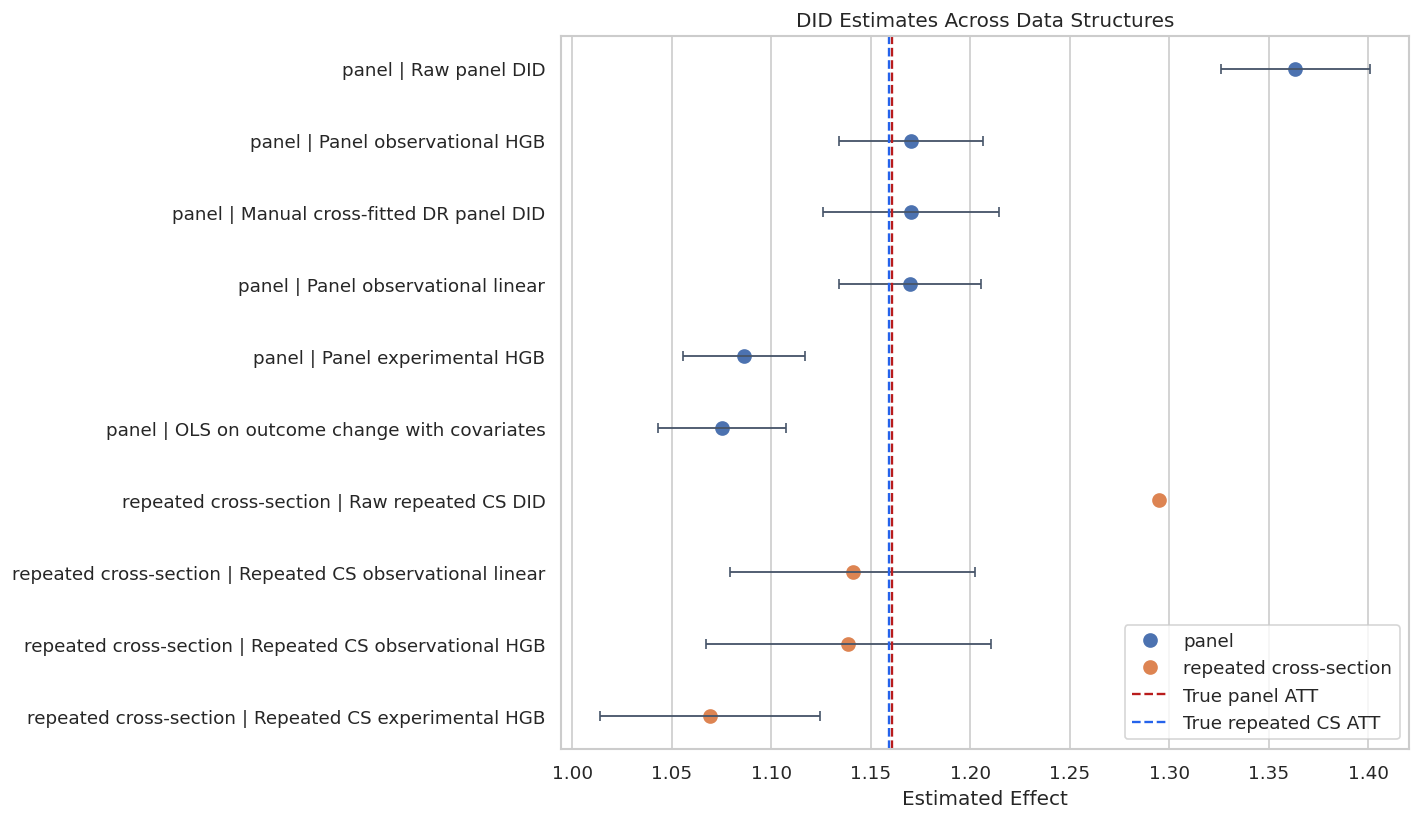

In [31]:
# Build and label the diagnostic visualization for the Combined Estimate Plot section.
plot_combined = combined_did_summary.dropna(subset=["theta_hat"]).copy()
plot_combined["label"] = plot_combined["section"] + " | " + plot_combined["estimator"]
plot_combined = add_ci_columns(plot_combined)

fig, ax = plt.subplots(figsize=(12, 7))
order = plot_combined.sort_values(["section", "theta_hat"], ascending=[True, False])["label"]
sns.pointplot(
    data=plot_combined,
    y="label",
    x="theta_hat",
    hue="section",
    order=order,
    linestyle="none",
    dodge=False,
    errorbar=None,
    ax=ax,
)
for y_pos, (_, row) in enumerate(plot_combined.set_index("label").loc[order].reset_index().iterrows()):
    if pd.notna(row["ci_95_lower"]):
        ax.errorbar(
            x=row["theta_hat"],
            y=y_pos,
            xerr=[[row["lower_error"]], [row["upper_error"]]],
            fmt="none",
            color="#475569",
            capsize=3,
            linewidth=1.1,
        )
ax.axvline(TRUE_PANEL_ATT, color="#b91c1c", linestyle="--", linewidth=1.4, label="True panel ATT")
ax.axvline(TRUE_CS_ATT, color="#2563eb", linestyle="--", linewidth=1.4, label="True repeated CS ATT")
ax.set_title("DID Estimates Across Data Structures")
ax.set_xlabel("Estimated Effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_combined_did_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The adjusted estimates cluster near their design-specific true targets. The raw estimates remain useful references, but they should not be treated as the main answer when assignment is observational and covariates predict trends.



#### What to Report in a DID Analysis

A DID report should not stop at a coefficient. It should tell readers what comparison created the estimate and why the counterfactual trend assumption is credible.

| topic | question | notebook_answer |
| --- | --- | --- |
| estimand | Is the target ATT, ATE, or another effect? | ATT for treated-group units in the post period. |
| data structure | Is the design panel or repeated cross-section? | Both are demonstrated separately. |
| treatment timing | Is exposure equal to treated group times post period? | Yes. Actual exposure is treated x post. |
| parallel trends | Why should untreated trends be comparable? | In the synthetic design, untreated trends depend on observed X. |
| overlap | Do treated and control groups share covariate support? | Propensity plots show adequate overlap. |
| placebo | Do pre-period placebo checks look near zero? | The adjusted placebo estimate is close to zero. |
| sensitivity | What happens under hidden trend violations? | Estimates move with the hidden trend, showing the design limit. |
| uncertainty | Are confidence intervals and split stability reported? | Yes. Analytic, bootstrap, and split-stability outputs are saved. |


This checklist is the bridge from notebook work to credible communication. A reader should be able to tell what would need to be true for the estimate to have a causal reading.

#### Report Template

The cell below writes a short Markdown report template. The values are filled from the notebook's main outputs, but the assumption language is deliberately cautious.

In [32]:
best_panel_row = panel_doubleml_summary.loc[panel_doubleml_summary["estimator"] == "Panel observational HGB"].iloc[0]
best_cs_row = cs_doubleml_summary.loc[cs_doubleml_summary["estimator"] == "Repeated CS observational HGB"].iloc[0]

report_text = f"""
# Difference-In-Differences DoubleML Report Template

## Question

Estimate the post-period effect for units in the treated group using DID designs with flexible nuisance adjustment.

## Panel DID Result

The preferred panel estimate is the observational `DoubleMLDID` model with gradient boosting nuisance learners.

- Estimate: {best_panel_row['theta_hat']:.4f}
- Standard error: {best_panel_row['std_error']:.4f}
- 95 percent CI: [{best_panel_row['ci_95_lower']:.4f}, {best_panel_row['ci_95_upper']:.4f}]
- Synthetic true ATT: {TRUE_PANEL_ATT:.4f}

## Repeated Cross-Section DID Result

The preferred repeated cross-section estimate is the observational `DoubleMLDIDCS` model with gradient boosting nuisance learners.

- Estimate: {best_cs_row['theta_hat']:.4f}
- Standard error: {best_cs_row['std_error']:.4f}
- 95 percent CI: [{best_cs_row['ci_95_lower']:.4f}, {best_cs_row['ci_95_upper']:.4f}]
- Synthetic true ATT: {TRUE_CS_ATT:.4f}

## Identification Assumptions

The estimates rely on conditional parallel trends: after conditioning on observed pre-treatment covariates, treated and control groups would have had comparable untreated trends. The estimates also require overlap, stable measurement, and no hidden group-specific shocks aligned with treatment timing.

## Diagnostics To Include

- Covariate balance by treated group.
- Propensity overlap plots.
- Raw DID versus adjusted DID comparison.
- Placebo pre-period check when historical outcomes are available.
- Stress test or sensitivity discussion for hidden trend violations.
- Clear statement of the target population.
""".strip()

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_did_report_template.md"
report_path.write_text(report_text)
print(report_text)


# Difference-In-Differences DoubleML Report Template

## Question

Estimate the post-period effect for units in the treated group using DID designs with flexible nuisance adjustment.

## Panel DID Result

The preferred panel estimate is the observational `DoubleMLDID` model with gradient boosting nuisance learners.

- Estimate: 1.1703
- Standard error: 0.0184
- 95 percent CI: [1.1343, 1.2064]
- Synthetic true ATT: 1.1606

## Repeated Cross-Section DID Result

The preferred repeated cross-section estimate is the observational `DoubleMLDIDCS` model with gradient boosting nuisance learners.

- Estimate: 1.1387
- Standard error: 0.0366
- 95 percent CI: [1.0670, 1.2104]
- Synthetic true ATT: 1.1592

## Identification Assumptions

The estimates rely on conditional parallel trends: after conditioning on observed pre-treatment covariates, treated and control groups would have had comparable untreated trends. The estimates also require overlap, stable measurement, and no hidden group-specific s

The report template keeps the coefficient tied to the design. That is the habit to build: every causal estimate should travel with its target, assumptions, diagnostics, and limitations.

The DID notebook is complete. The next natural topic is sample-selection models, where the challenge shifts from before-after counterfactual trends to outcomes that are only observed for selected units.